In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Project 2 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the Cats and Dogs data set (and maybe a subset of the MNIST data set).

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

In [2]:
# In the last project we have already seen example of the MNIST data set. Here we take a look at Cats and Dogs

import pandas as pd

PATHIM = "/content/drive/MyDrive/images.csv"
PATHLB = "/content/drive/MyDrive/labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels["label"].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


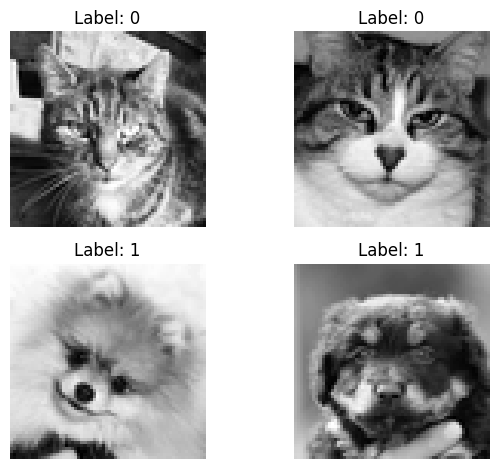

In [3]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

#Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

# Part 1

*Everyone should do this task.*

For the first part, use the provided Cats and Dogs data set.

Use at least 3 different classifiers and at least 2 feature selection methods.

For example, you can use filtering or wrappers in conjuction with any of the classifiers (using e.g. threshholds on the importance, t-tests/F-tests or CV-error with forward selection etc). I.e., for the filtering method you choose a test or scoring mechanism and use CV to determine the optimal threshold.

For the wrapper method you choose, e.g., forward selection or backward selection, CV is used when to stop adding features. Here, the scoring mechanism to decide which order to drop/add features can be based on drop/increase in predictive performance, importance metrics, etc.

The embedding methods we have talked about in class is lasso/elastic net which is used with multinomial/logistic regression. For the embedding methods, CV is used to choose the penalty parameter.

Note, you can also use a combination of techniques - perhaps you want to filter the features before you use wrappers or embedding methods?

Questions to answer

1. Using CV, determine how many features (pixels) you need for classification. Does the optimal number of features differ between the approaches?

2. Which pixels are selected? Does this differ between the approaches/classification methods? (Can you think of why?)

3. Repeat the above a few times - is the selection stable? (meaning the number of features needed and/or which pixels are chosen is roughly the same across multiple runs).



##Method: T-test + Top-K Feature (Pixel) Selection

**Our Process**
- A T-test here is used to measure how different each pixel is between cat and dog images by comparing the average pixel values across the two classes; pixels with higher absolute t-scores are considered more discriminative.
- A 5-fold cross-validation was performed on the training set, where the T-test-based feature ranking was computed only within each training fold to avoid data leakage, and evaluated on the corresponding validation folds.
- For each model, different numbers of top-ranked pixels (10, 50, 100, 500, 1000, 2000, 4096) were tested, and the subset that achieved the highest cross-validation accuracy was selected as the best configuration for that model.
- The selected pixel subset for each model was then used to train on the full training set and evaluated on the held-out test set.
- This entire procedure was repeated over 5 different random train-test splits to ensure robustness of results.
- Finally, a majority vote across the 5 runs was used to determine the final optimal number of pixels per model; for example, if KNN achieved its best performance with 2000 pixels in 3 out of 5 runs, then 2000 pixels was selected as the final feature subset for KNN.

In [4]:
print(images.shape)   # should be (10000, 4096)
print(labels.shape)   # should be (10000,)
print(np.unique(labels, return_counts=True))  # how many cats vs dogs?

(10000, 4096)
(10000,)
(array([0, 1]), array([5000, 5000]))


In [5]:
# Get indices for each class
cat_idx = np.where(labels == 0)[0]
dog_idx = np.where(labels == 1)[0]

# Randomly pick 1000 from each
rng = np.random.RandomState(42)
cat_selected = rng.choice(cat_idx, 1000, replace=False)
dog_selected = rng.choice(dog_idx, 1000, replace=False)

# Combine and shuffle
selected_idx = np.concatenate([cat_selected, dog_selected])
rng.shuffle(selected_idx)

X_sub = images[selected_idx]
y_sub = labels[selected_idx]

# Sanity check
print(f"Subset image shape: {X_sub.shape}")                              # (2000, 4096)
print(f"Class counts: {np.unique(y_sub, return_counts=True)}")     # 1000 cats, 1000 dogs

Subset image shape: (2000, 4096)
Class counts: (array([0, 1]), array([1000, 1000]))


In [6]:
num_cats = np.sum(y_sub == 0)
num_dogs = np.sum(y_sub == 1)

print(f"Number of Cats: {num_cats}")
print(f"Number of Dogs: {num_dogs}")

if num_cats == 1000 and num_dogs == 1000:
    print("Success: The subset contains exactly 1000 cats and 1000 dogs.")
else:
    print("Warning: The distribution does not match the target.")

Number of Cats: 1000
Number of Dogs: 1000
Success: The subset contains exactly 1000 cats and 1000 dogs.



══════════════════════════════════════════════════════════
  ITERATION 1 / 5
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Dataset Split
──────────────────────────────────────────────────────────
  Train    1600 samples  │  Cats:  800  Dogs:  800
  Test      400 samples  │  Cats:  200  Dogs:  200

──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.6800    0.6544          0.6794
        50  │           0.7075    0.6400          0.5781
       100  │           0.7187    0.6569          0.6256
       500  │           0.8181    0.7612          0.7125
      1000  │           0.8206    0.7438          0.7350
      2000  │           0.8269    0.7037          0.7569
 

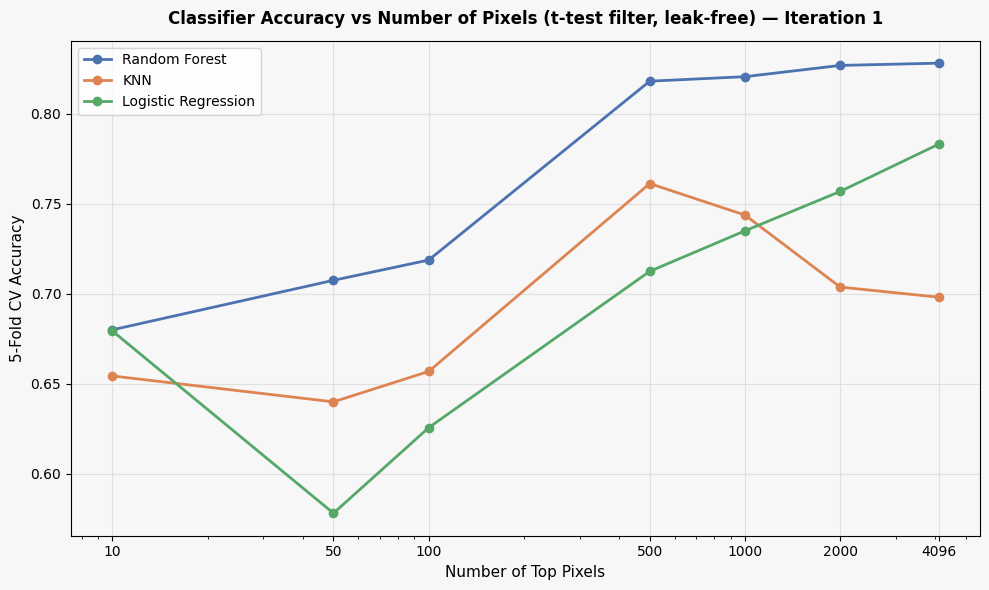


──────────────────────────────────────────────────────────
  Best Performance Summary (t-test filter)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                     4096      0.8281
  KNN                                500      0.7612
  Logistic Regression               4096      0.7831

  Optimal t-test feature indices saved based on training data.

──────────────────────────────────────────────────────────
  Final Test Evaluation (t-test Selected Pixels)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest               4096          0.8450
  KNN                          500          0.7625
  Logistic Regression         4096          0.7525


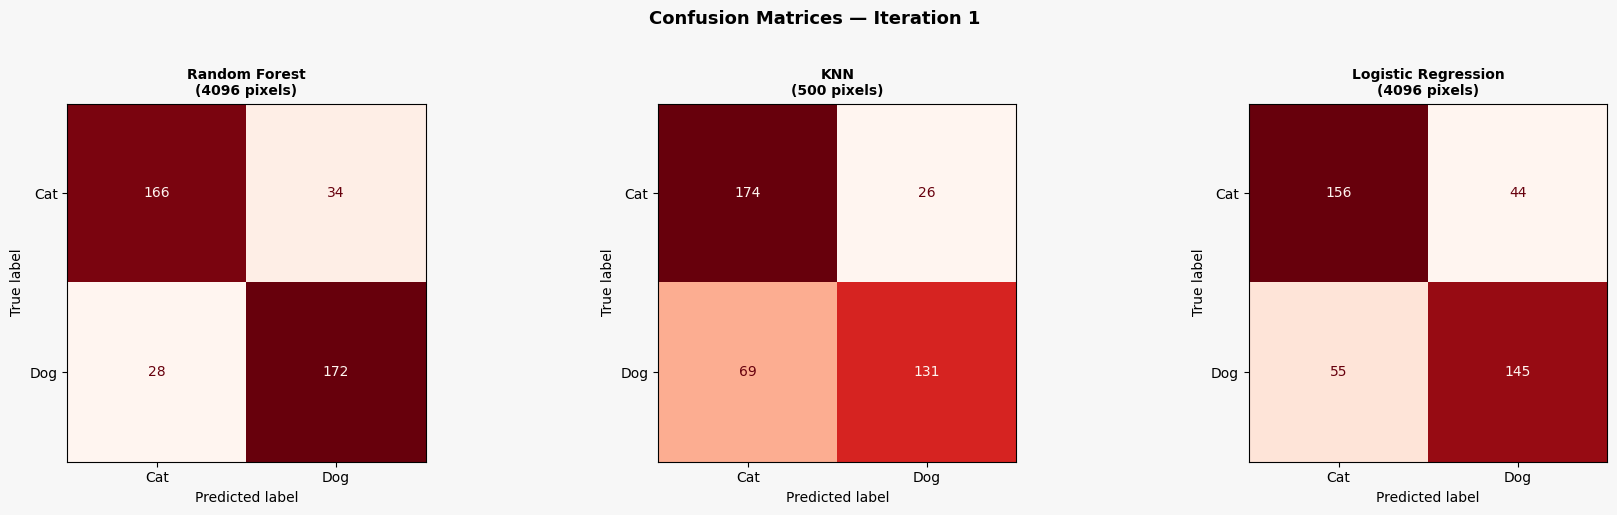

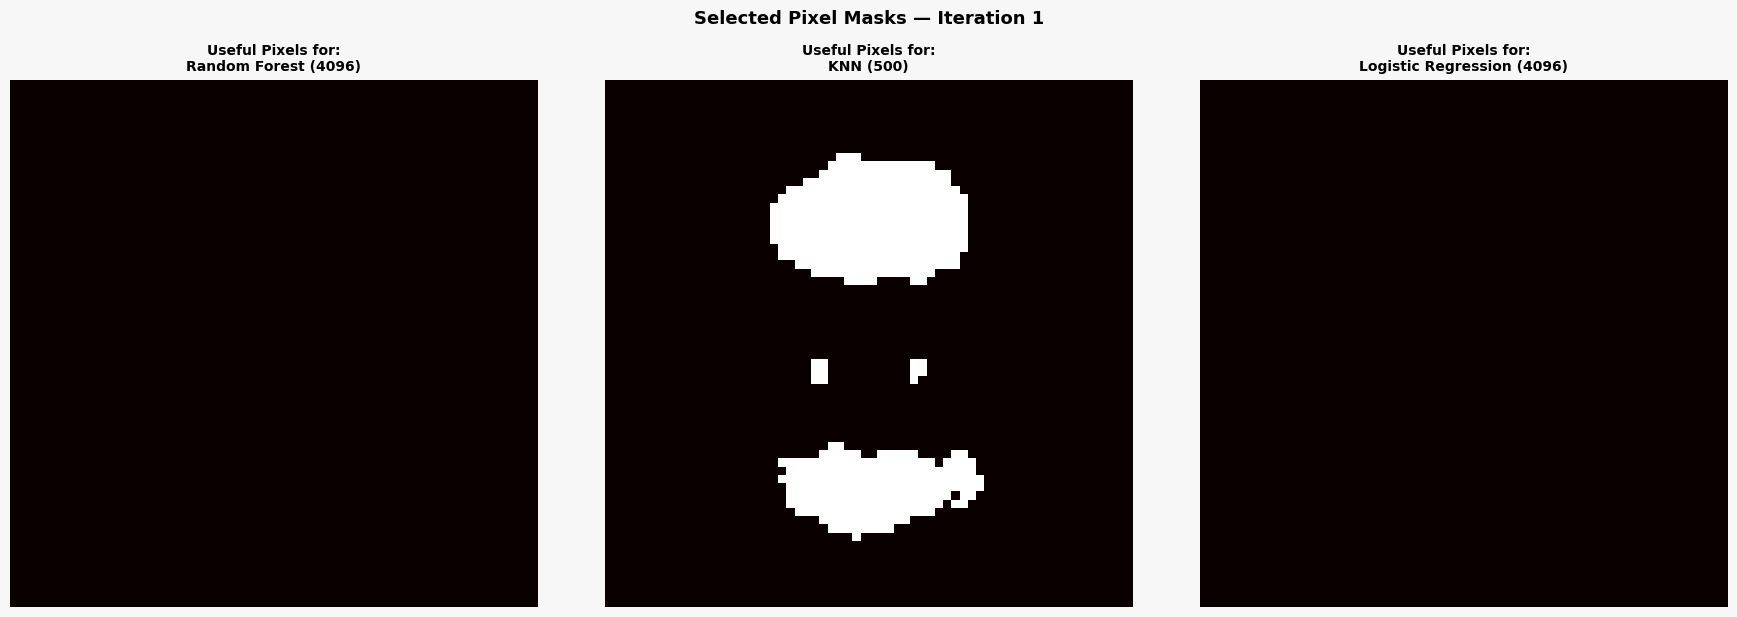


══════════════════════════════════════════════════════════
  ITERATION 2 / 5
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Dataset Split
──────────────────────────────────────────────────────────
  Train    1600 samples  │  Cats:  800  Dogs:  800
  Test      400 samples  │  Cats:  200  Dogs:  200

──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.6838    0.6281          0.6731
        50  │           0.7075    0.6475          0.5650
       100  │           0.7194    0.6438          0.6281
       500  │           0.8213    0.7688          0.7044
      1000  │           0.8244    0.7506          0.7300
      2000  │           0.8319    0.7025          0.7425
 

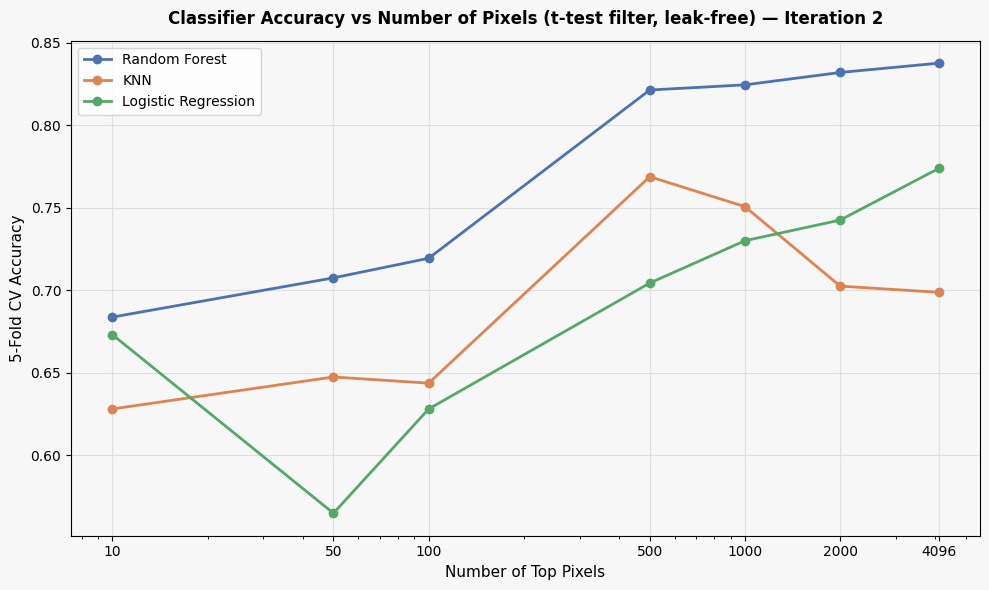


──────────────────────────────────────────────────────────
  Best Performance Summary (t-test filter)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                     4096      0.8375
  KNN                                500      0.7688
  Logistic Regression               4096      0.7738

  Optimal t-test feature indices saved based on training data.

──────────────────────────────────────────────────────────
  Final Test Evaluation (t-test Selected Pixels)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest               4096          0.8425
  KNN                          500          0.7525
  Logistic Regression         4096          0.7850


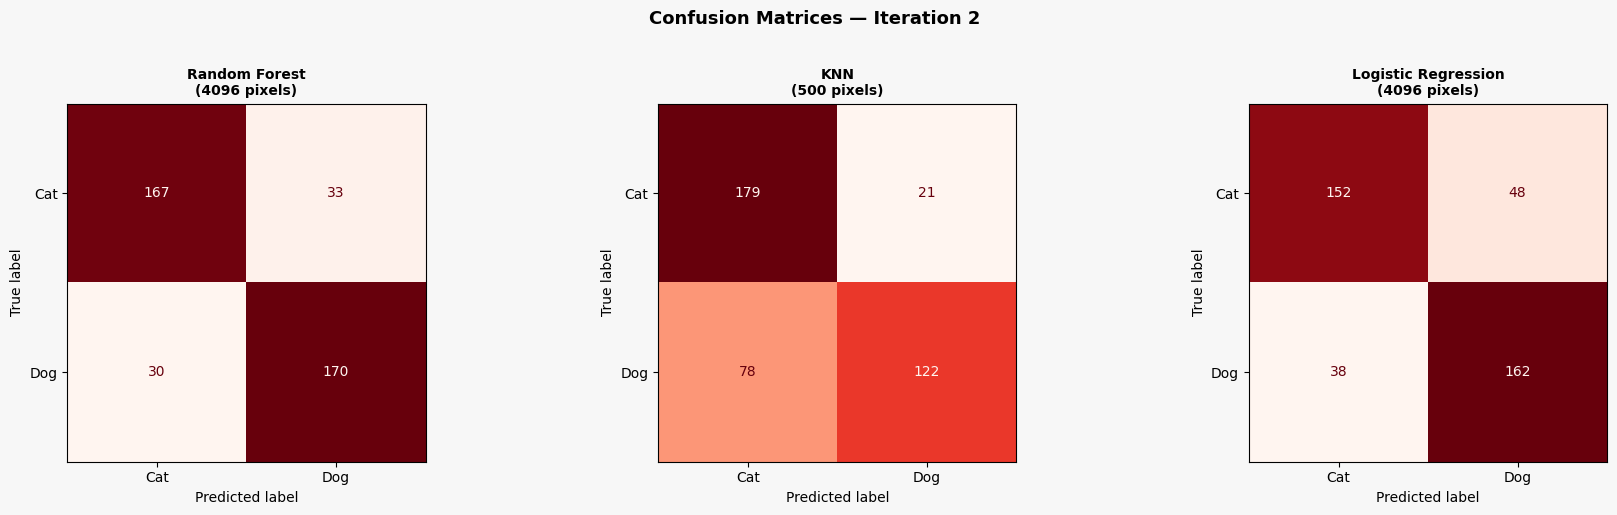

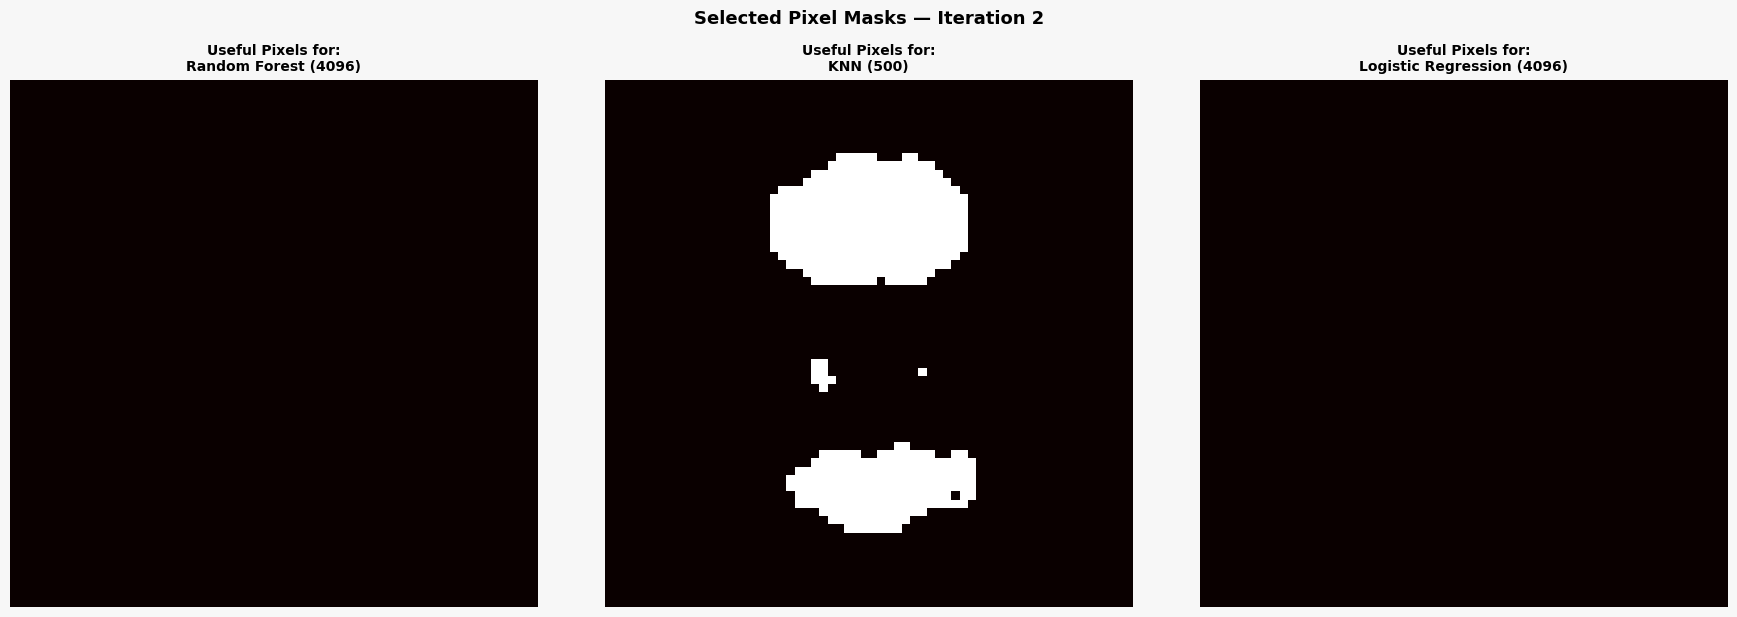


══════════════════════════════════════════════════════════
  ITERATION 3 / 5
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Dataset Split
──────────────────────────────────────────────────────────
  Train    1600 samples  │  Cats:  800  Dogs:  800
  Test      400 samples  │  Cats:  200  Dogs:  200

──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.6794    0.6631          0.6869
        50  │           0.7056    0.6356          0.5750
       100  │           0.7006    0.6494          0.6056
       500  │           0.8025    0.7594          0.7213
      1000  │           0.8181    0.7506          0.7225
      2000  │           0.8294    0.7125          0.7456
 

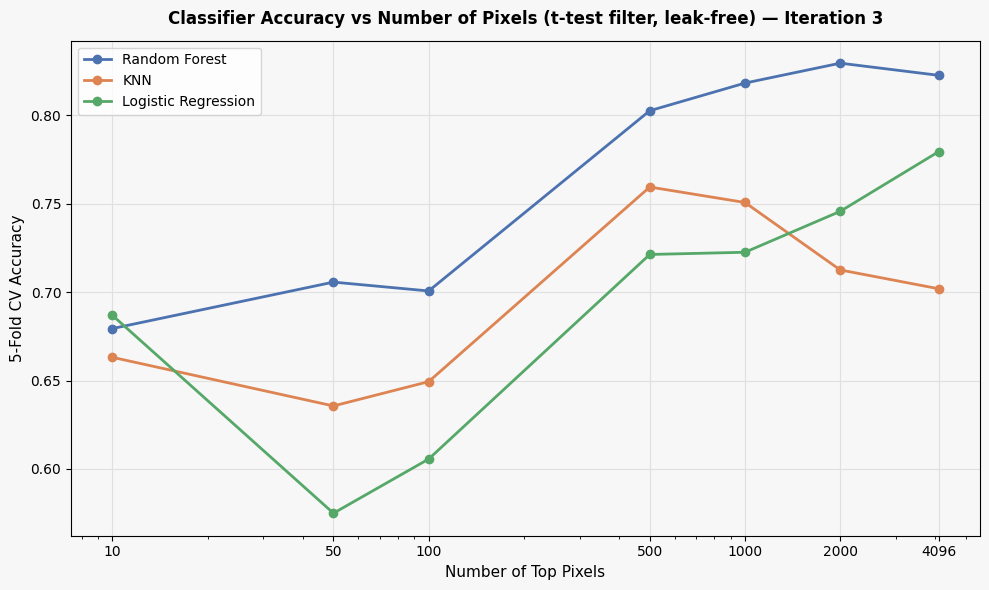


──────────────────────────────────────────────────────────
  Best Performance Summary (t-test filter)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                     2000      0.8294
  KNN                                500      0.7594
  Logistic Regression               4096      0.7794

  Optimal t-test feature indices saved based on training data.

──────────────────────────────────────────────────────────
  Final Test Evaluation (t-test Selected Pixels)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest               2000          0.8650
  KNN                          500          0.7800
  Logistic Regression         4096          0.7950


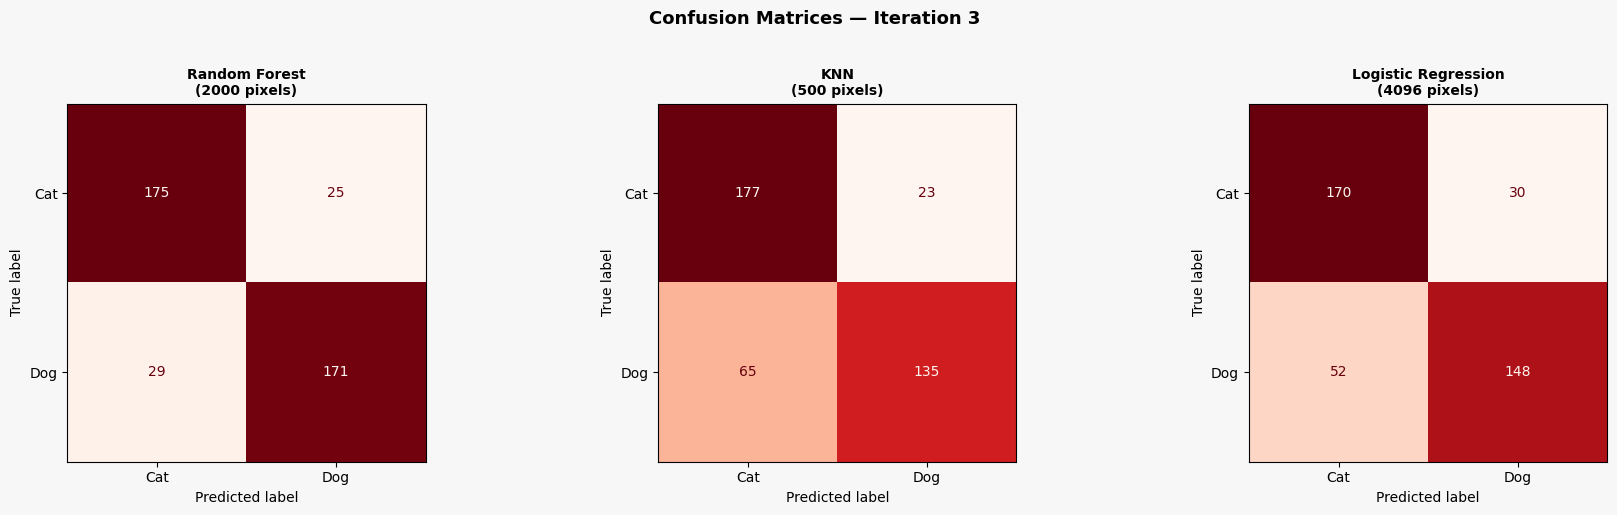

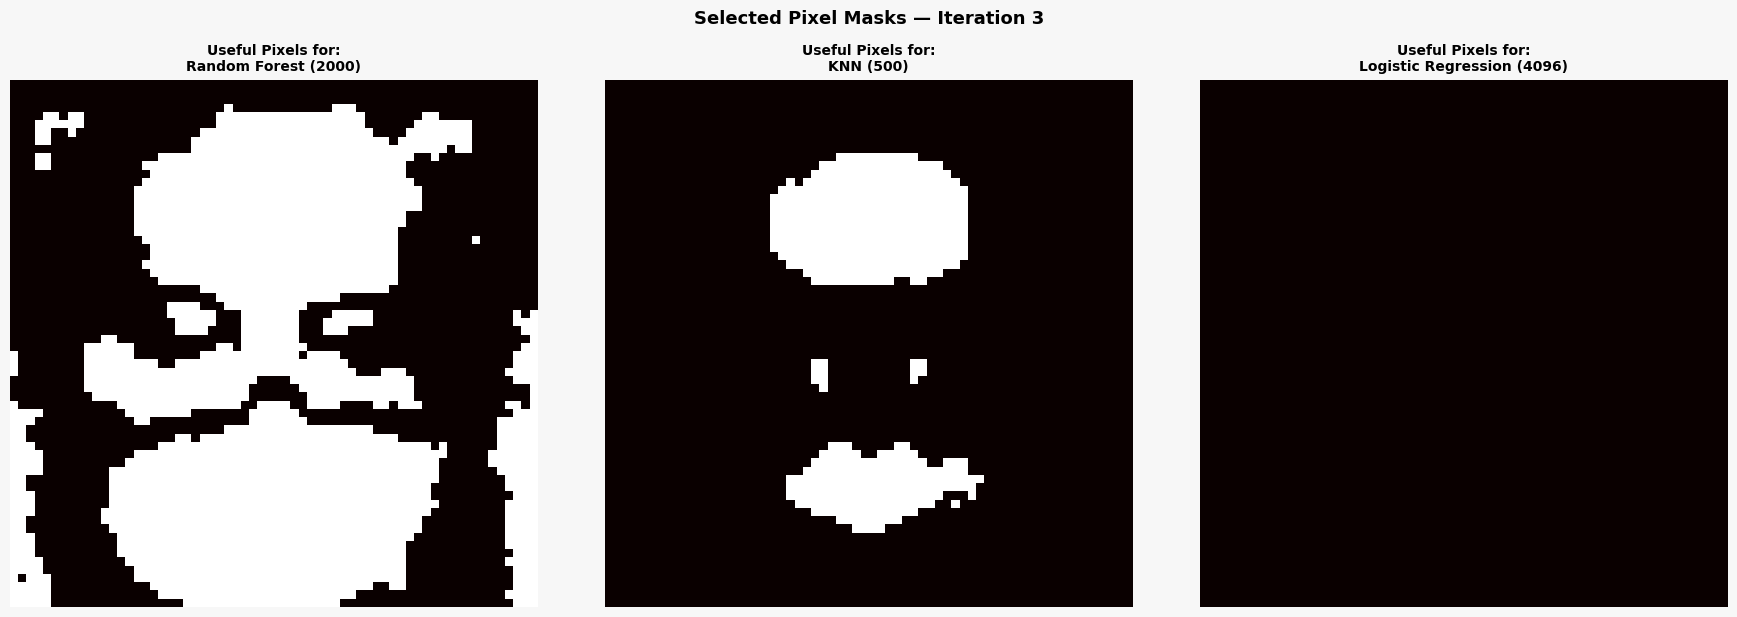


══════════════════════════════════════════════════════════
  ITERATION 4 / 5
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Dataset Split
──────────────────────────────────────────────────────────
  Train    1600 samples  │  Cats:  800  Dogs:  800
  Test      400 samples  │  Cats:  200  Dogs:  200

──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.7044    0.6494          0.6937
        50  │           0.7150    0.6250          0.5706
       100  │           0.7112    0.6400          0.6219
       500  │           0.8050    0.7606          0.7131
      1000  │           0.8012    0.7569          0.7087
      2000  │           0.8244    0.7175          0.7512
 

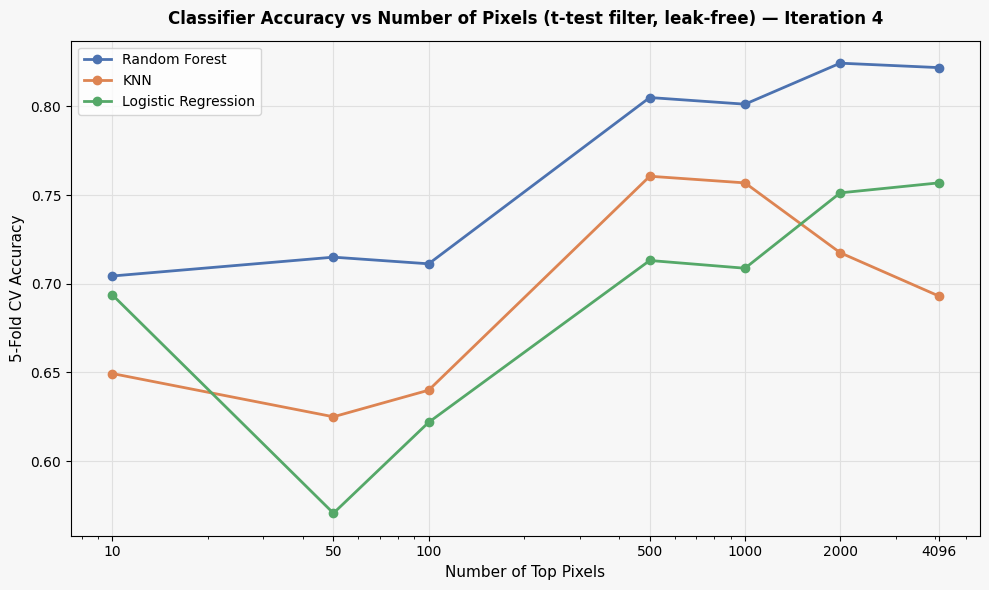


──────────────────────────────────────────────────────────
  Best Performance Summary (t-test filter)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                     2000      0.8244
  KNN                                500      0.7606
  Logistic Regression               4096      0.7569

  Optimal t-test feature indices saved based on training data.

──────────────────────────────────────────────────────────
  Final Test Evaluation (t-test Selected Pixels)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest               2000          0.8825
  KNN                          500          0.7725
  Logistic Regression         4096          0.7475


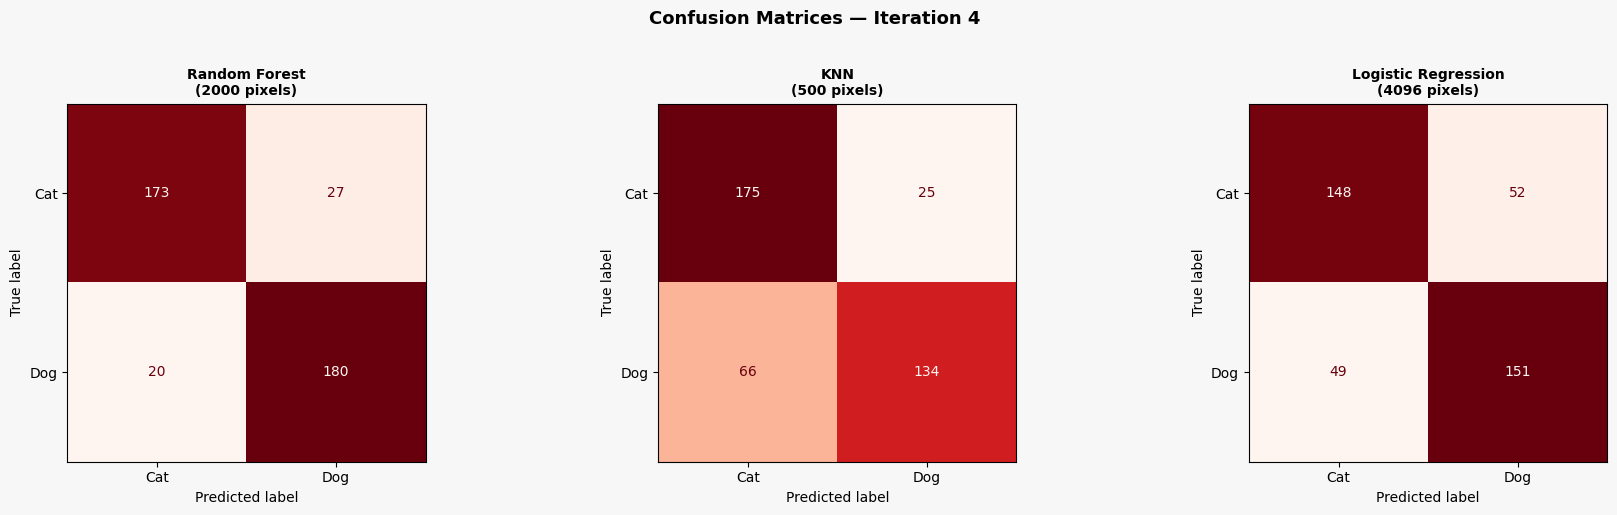

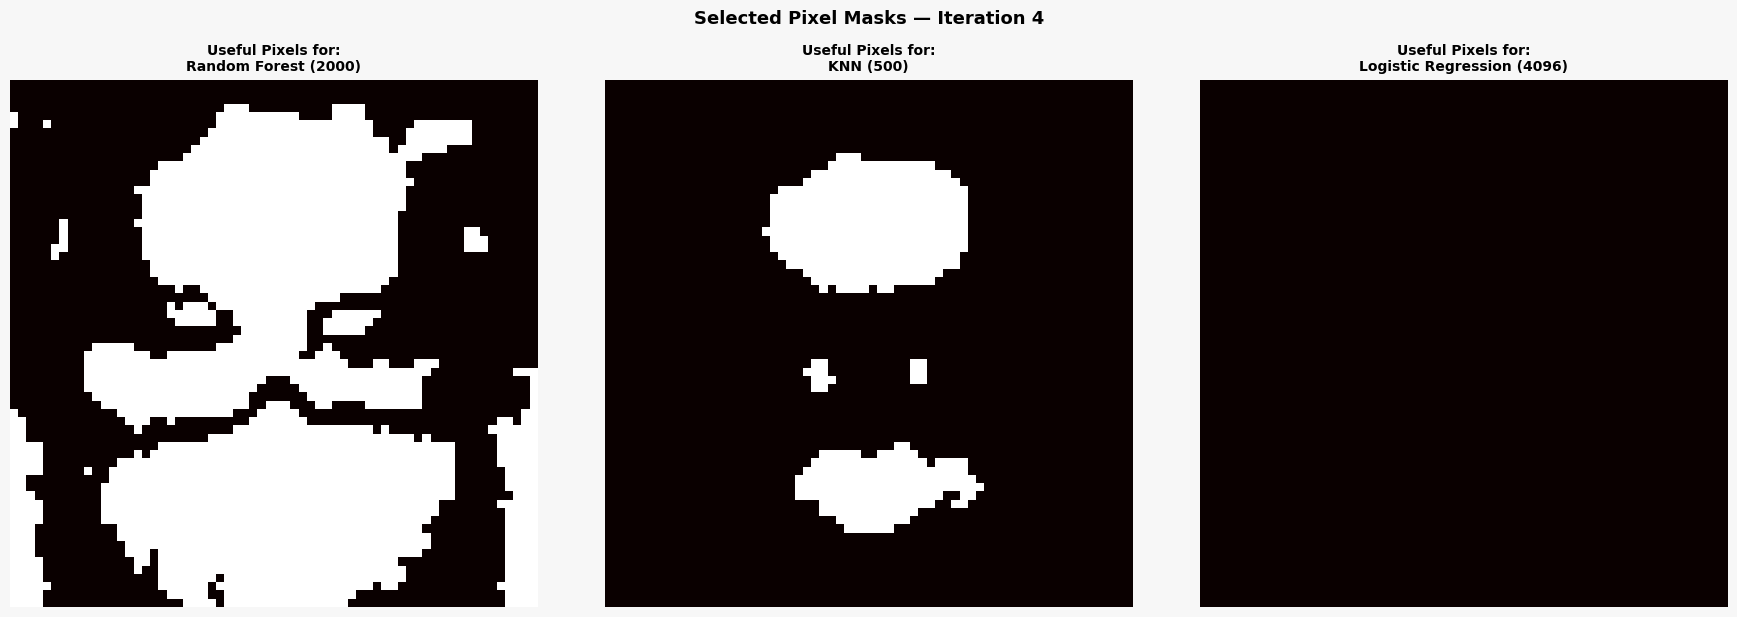


══════════════════════════════════════════════════════════
  ITERATION 5 / 5
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Dataset Split
──────────────────────────────────────────────────────────
  Train    1600 samples  │  Cats:  800  Dogs:  800
  Test      400 samples  │  Cats:  200  Dogs:  200

──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.6775    0.6350          0.6781
        50  │           0.7062    0.6375          0.5787
       100  │           0.7037    0.6575          0.6069
       500  │           0.8106    0.7525          0.7188
      1000  │           0.8138    0.7506          0.7162
      2000  │           0.8281    0.7019          0.7513
 

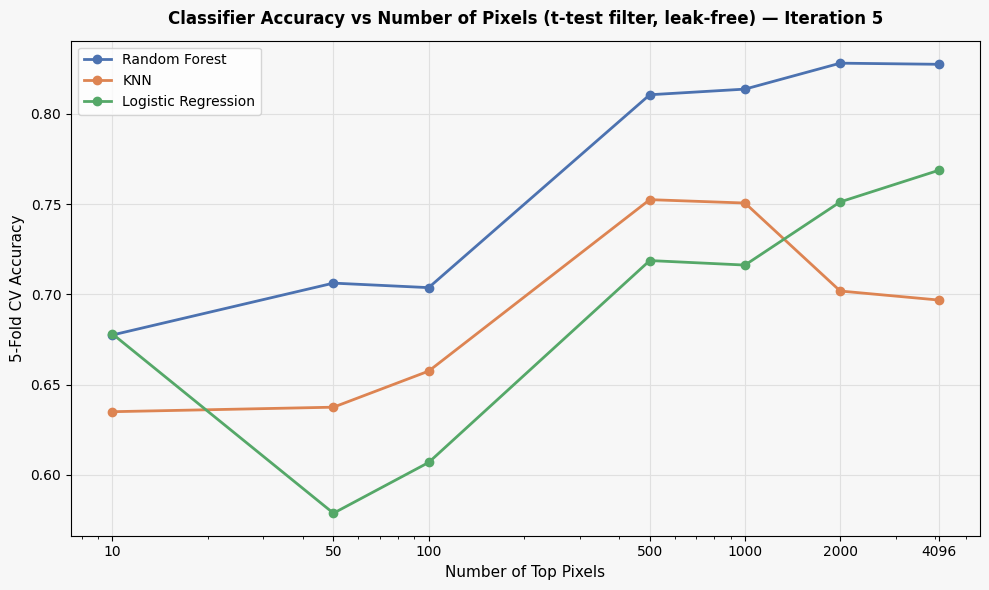


──────────────────────────────────────────────────────────
  Best Performance Summary (t-test filter)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                     2000      0.8281
  KNN                                500      0.7525
  Logistic Regression               4096      0.7687

  Optimal t-test feature indices saved based on training data.

──────────────────────────────────────────────────────────
  Final Test Evaluation (t-test Selected Pixels)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest               2000          0.8600
  KNN                          500          0.7925
  Logistic Regression         4096          0.7800


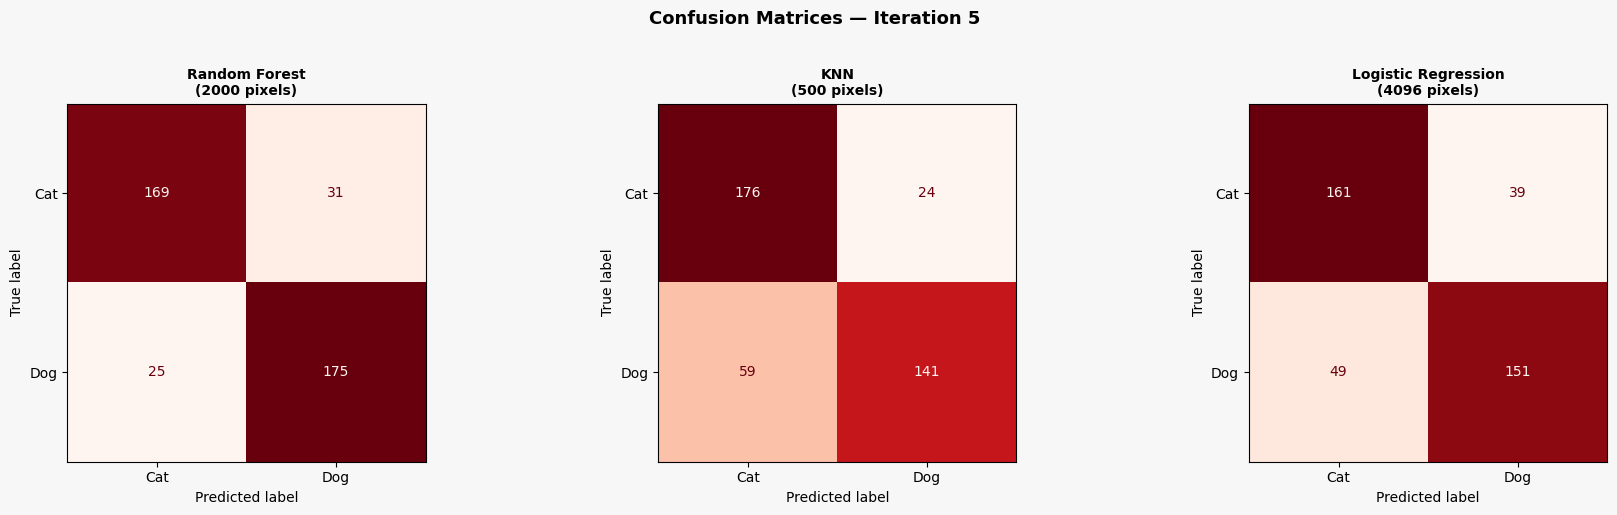

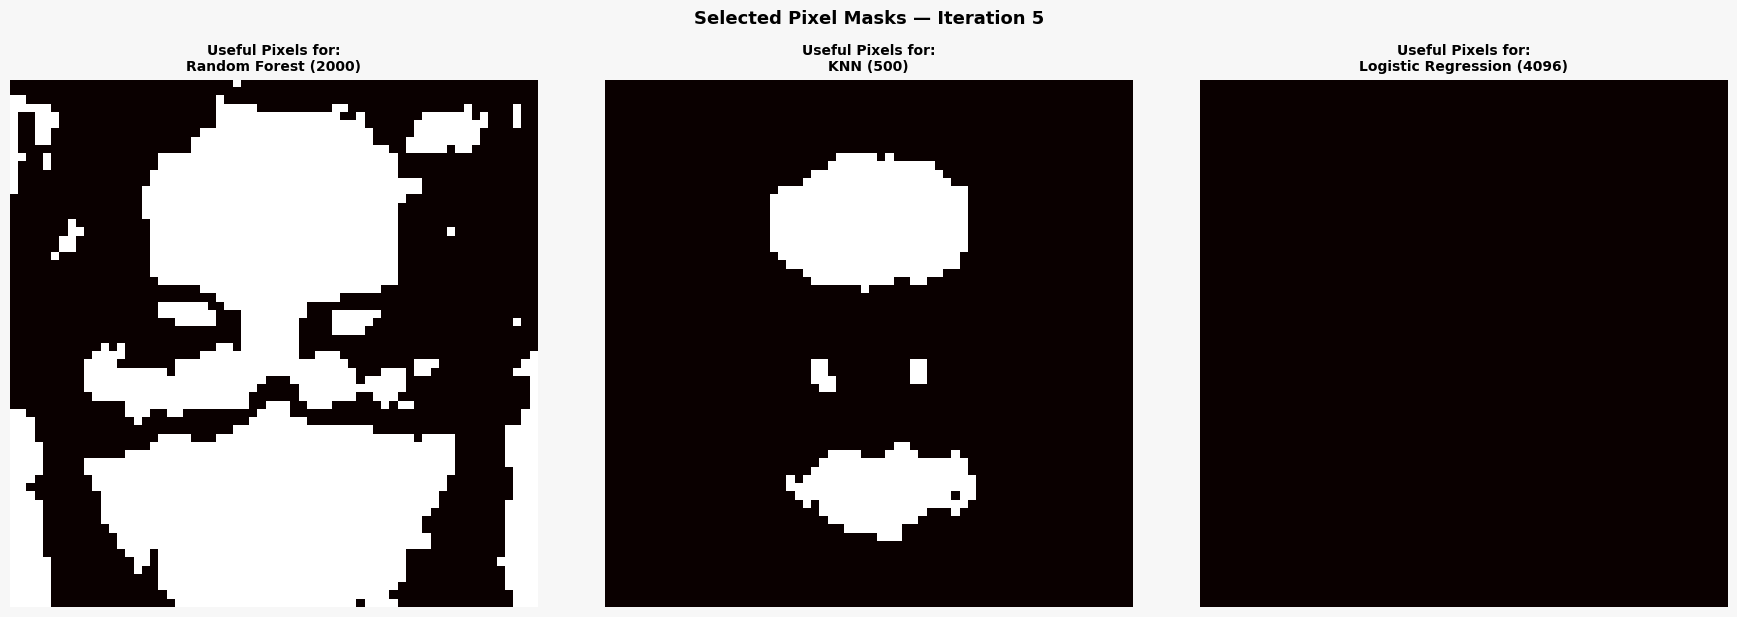

In [7]:
import warnings
warnings.filterwarnings('ignore')  # Suppress convergence warnings

# All imports moved outside loop (fix 5)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import ttest_ind

# ── Style ──────────────────────────────────────────────────────
PALETTE = {
    "Random Forest":       "#4C72B0",
    "KNN":                 "#DD8452",
    "Logistic Regression": "#55A868",
}
BG     = "#F7F7F7"
GRID_C = "#E0E0E0"

num_features_to_test = [10, 50, 100, 500, 1000, 2000, 4096]

# Classifiers unchanged from original
models = {
    "Random Forest":       lambda: RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":                 lambda: KNeighborsClassifier(n_neighbors=5, weights='distance', metric = 'euclidean'),
    "Logistic Regression": lambda: LogisticRegression(C=0.01,random_state=42),
}

def get_best_n_per_model(results_dict, feature_list):
    best_configs = {}
    for model_name, scores in results_dict.items():
        best_idx = np.argmax(scores)
        best_configs[model_name] = (feature_list[best_idx], scores[best_idx])
    return best_configs

def section(title):
    print(f"\n{'─' * 58}")
    print(f"  {title}")
    print(f"{'─' * 58}")

# ───────────────────────────────────────────────────────────────
for count in range(5):

    print(f"\n{'═' * 58}")
    print(f"  ITERATION {count + 1} / 5")
    print(f"{'═' * 58}")

    # No random_state → different split each iteration
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, stratify=y_sub
    )

    train_cats = np.sum(y_train == 0)
    train_dogs = np.sum(y_train == 1)
    test_cats  = np.sum(y_test  == 0)
    test_dogs  = np.sum(y_test  == 1)

    section("Dataset Split")
    print(f"  {'Train':6s}  {X_train.shape[0]:>5d} samples  │  Cats: {train_cats:>4d}  Dogs: {train_dogs:>4d}")
    print(f"  {'Test':6s}  {X_test.shape[0]:>5d} samples  │  Cats: {test_cats:>4d}  Dogs: {test_dogs:>4d}")

    # Fix 1: results reset each iteration
    # Fix 2: random_state=count so folds differ across iterations
    # Fix 4: split X_train only (not X_sub) to avoid test set leakage in CV
    results = {name: [] for name in models}
    skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=count)

    section("Cross-Validation  (5-Fold, t-test pixel filter)")
    print(f"  {'Features':>8}  │  {'Random Forest':>15}  {'KNN':>8}  {'Logistic Reg':>14}")
    print(f"  {'─'*8}  │  {'─'*15}  {'─'*8}  {'─'*14}")

    for n in num_features_to_test:
        fold_results = {name: [] for name in models}

        # Fix 4: CV over X_train/y_train only, not X_sub/y_sub
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_train_cv, X_val_cv = X_train[train_idx], X_train[val_idx]
            y_train_cv, y_val_cv = y_train[train_idx], y_train[val_idx]

            # t-test on training fold only — no leakage
            cats = X_train_cv[y_train_cv == 0]
            dogs = X_train_cv[y_train_cv == 1]
            t_stats, _ = ttest_ind(cats, dogs, axis=0)
            top_indices = np.argsort(np.abs(t_stats))[::-1][:n]

            for name, clf_fn in models.items():
                clf = clf_fn()  # fresh instance each fold
                clf.fit(X_train_cv[:, top_indices], y_train_cv)
                acc = clf.score(X_val_cv[:, top_indices], y_val_cv)
                fold_results[name].append(acc)

        row_scores = []
        for name in models:
            mean_acc = np.mean(fold_results[name])
            results[name].append(mean_acc)
            row_scores.append(f"{mean_acc:.4f}")

        print(f"  {n:>8d}  │  {row_scores[0]:>15}  {row_scores[1]:>8}  {row_scores[2]:>14}")

    # ── Accuracy vs features plot ───────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    for name, scores in results.items():
        ax.plot(num_features_to_test, scores,
                marker='o', linewidth=2, markersize=6,
                label=name, color=PALETTE[name])

    ax.set_title(f'Classifier Accuracy vs Number of Pixels (t-test filter, leak-free) — Iteration {count + 1}',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Number of Top Pixels', fontsize=11)
    ax.set_ylabel('5-Fold CV Accuracy',   fontsize=11)
    ax.set_xscale('log')
    ax.set_xticks(num_features_to_test)
    ax.set_xticklabels(num_features_to_test)
    ax.grid(True, color=GRID_C, linewidth=0.8)
    ax.legend(frameon=True, fontsize=10)
    plt.tight_layout()
    plt.show()

    # Fix 3: use best_t from CV results instead of hardcoded values
    best_t = get_best_n_per_model(results, num_features_to_test)

    section("Best Performance Summary (t-test filter)")
    print(f"  {'Model':22s}  {'Optimal Pixels':>14}  {'Max CV Acc':>10}")
    print(f"  {'─'*22}  {'─'*14}  {'─'*10}")
    for model, (n, acc) in best_t.items():
        print(f"  {model:22s}  {n:>14d}  {acc:>10.4f}")

    # ── Optimal feature sets from training data only ────────────
    optimal_feature_sets = {}

    cats_tr = X_train[y_train == 0]
    dogs_tr = X_train[y_train == 1]
    t_stats_tr, _    = ttest_ind(cats_tr, dogs_tr, axis=0)
    absolute_t_stats = np.argsort(np.abs(t_stats_tr))[::-1]

    # Fix 3: use best_t dynamically instead of hardcoded 2000/500/4096
    optimal_feature_sets['Random Forest']       = absolute_t_stats[:best_t['Random Forest'][0]]
    optimal_feature_sets['KNN']                 = absolute_t_stats[:best_t['KNN'][0]]
    optimal_feature_sets['Logistic Regression'] = absolute_t_stats[:best_t['Logistic Regression'][0]]

    print("\n  Optimal t-test feature indices saved based on training data.")

    # ── Final test evaluation ───────────────────────────────────
    section("Final Test Evaluation (t-test Selected Pixels)")
    print(f"  {'Model':22s}  {'Pixels':>8}  {'Test Accuracy':>14}")
    print(f"  {'─'*22}  {'─'*8}  {'─'*14}")

    for model_name, indices in optimal_feature_sets.items():
        X_tr_fixed = X_train[:, indices]
        X_te_fixed = X_test[:, indices]

        clf = models[model_name]()
        clf.fit(X_tr_fixed, y_train)
        score = clf.score(X_te_fixed, y_test)
        print(f"  {model_name:22s}  {len(indices):>8d}  {score:>14.4f}")

    # ── Confusion matrices ──────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor(BG)
    fig.suptitle(f'Confusion Matrices — Iteration {count + 1}',
                 fontsize=13, fontweight='bold', y=1.02)

    for i, (model_name, indices) in enumerate(optimal_feature_sets.items()):
        X_tr_fixed = X_train[:, indices]
        X_te_fixed = X_test[:, indices]

        clf = models[model_name]()
        clf.fit(X_tr_fixed, y_train)
        y_pred = clf.predict(X_te_fixed)

        cm   = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
        disp.plot(ax=axes[i], cmap='Reds', colorbar=False)
        axes[i].set_facecolor(BG)
        axes[i].set_title(f"{model_name}\n({len(indices)} pixels)",
                          fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ── Pixel importance maps ───────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor(BG)
    fig.suptitle(f'Selected Pixel Masks — Iteration {count + 1}',
                 fontsize=13, fontweight='bold', y=1.02)

    for i, (model_name, indices) in enumerate(optimal_feature_sets.items()):
        mask          = np.zeros(4096)
        mask[indices] = 1
        mask_img      = mask.reshape(64, 64)

        im = axes[i].imshow(mask_img, cmap='hot')
        axes[i].set_title(f"Useful Pixels for:\n{model_name} ({len(indices)})",
                          fontsize=10, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## Summary of Model Performance Across Iterations

To ensure the results are robust and not a random fluke, we repeated the training and evaluation process across 5 random splits. Below is the summary of the optimal feature count found via CV and the resulting test accuracy.

| Iteration | Random Forest (Pixels / Acc) | KNN (Pixels / Acc) | Logistic Regression (Pixels / Acc) |
|:---:|:---:|:---:|:---:|
| **1** | 4096 / 0.8450 | 500 / 0.7625 | 4096 / 0.7525 |
| **2** | 4096 / 0.8425 | 500 / 0.7525 | 4096 / 0.7850 |
| **3** | 2000 / 0.8650 | 500 / 0.7800 | 4096 / 0.7950 |
| **4** | 2000 / 0.8825 | 500 / 0.7725 | 4096 / 0.7475 |
| **5** | 2000 / 0.8281 | 500 / 0.7525 | 4096 / 0.7687 |


Best t-test pixels for each model:
- Random Forest - 2000 (3/5 Iterations)
- KNN - 500 (5/5 Iterations)
- Logistic Regression - 4096 (5/5 Iterations)



## Analysis and Answer to Questions

**Q1 — How many features do you need, and does it differ between approaches?**

- The optimal number of features differs clearly between models. KNN consistently converged on 500 pixels across all 5 iterations, while Logistic Regression always preferred 4096 (all pixels). Random Forest was less consistent, choosing either 2000 or 4096 depending on the split. This suggests that simpler distance-based models like KNN benefit from aggressive feature reduction to avoid the curse of dimensionality, while Logistic Regression with strong regularization (C=0.01) can handle all pixels without overfitting since the penalty already suppresses irrelevant features internally.

**Q2 — Which pixels are selected, and does it differ between models?**

- Since all three models use the same t-test filter to rank pixels, the ranking of pixels is identical. The difference is only in how many top-ranked pixels each model uses. So RF and LR selecting 2000–4096 pixels use a superset of the 500 pixels KNN uses.

**Q3 — Is the selection stable across runs?**

- For KNN and Logistic Regression, yes it is perfectly stable. KNN chose 500 in all 5 runs, LR chose 4096 in all 5 runs. Random Forest was moderately stable, choosing 2000 in 3 runs and 4096 in 2 runs. However, I would still be hesitant to draw conclusions for RF and would need more iterations.

## Theme 2 - Image Flip Analysis
In this section, we flip 50% of the images in each class upside down to see how it affects feature selection and classification accuracy.

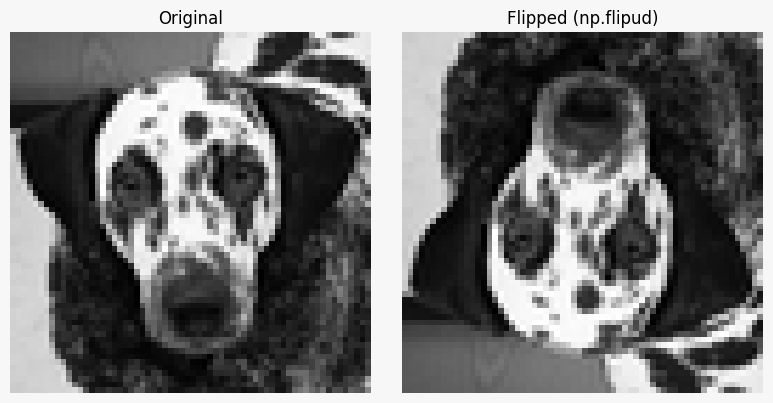


══════════════════════════════════════════════════════════
  ITERATION 1 / 5  —  Theme 2: Image Flip Analysis
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Flip Distribution
──────────────────────────────────────────────────────────


,Set,Total Cats,Flipped Cats,Normal Cats,Total Dogs,Flipped Dogs,Normal Dogs
0,Training,800,400,400,800,400,400
1,Test,200,100,100,200,100,100



──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.6469    0.6250          0.5712
        50  │           0.6600    0.5900          0.5400
       100  │           0.6794    0.6188          0.5312
       500  │           0.7087    0.6819          0.5875
      1000  │           0.7031    0.6819          0.5787
      2000  │           0.7250    0.6319          0.5931
      4096  │           0.7250    0.6219          0.5813


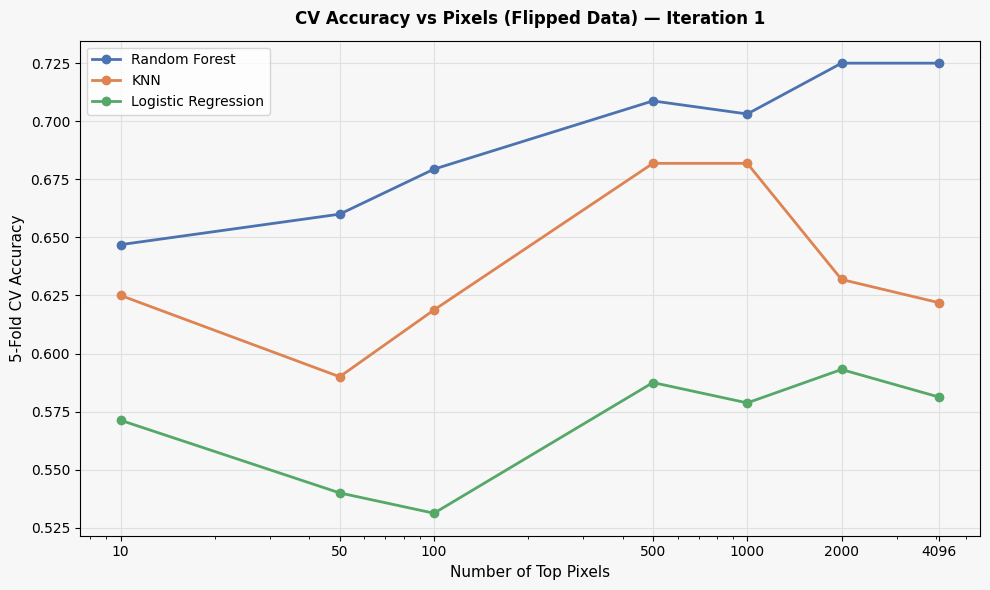


──────────────────────────────────────────────────────────
  Best Config per Model  (Flipped Data)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                     2000      0.7250
  KNN                                500      0.6819
  Logistic Regression               2000      0.5931

──────────────────────────────────────────────────────────
  Final Test Evaluation (Flipped Data)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest               2000          0.7050
  KNN                          500          0.6375
  Logistic Regression         2000          0.5650


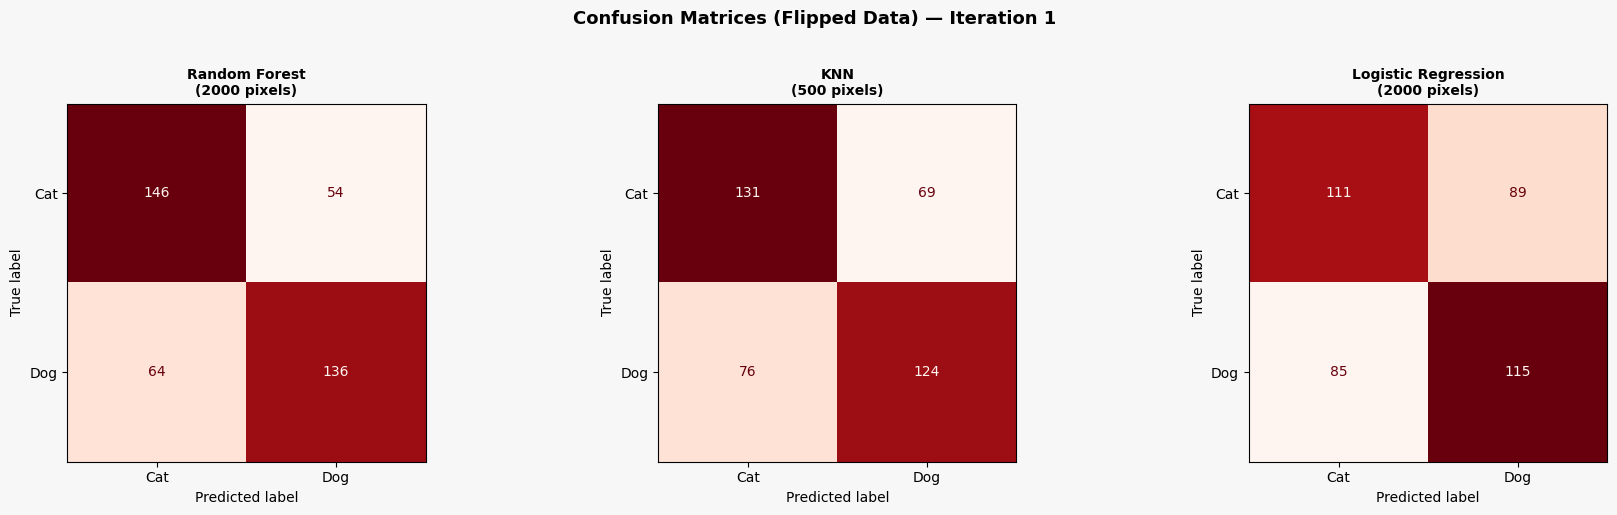

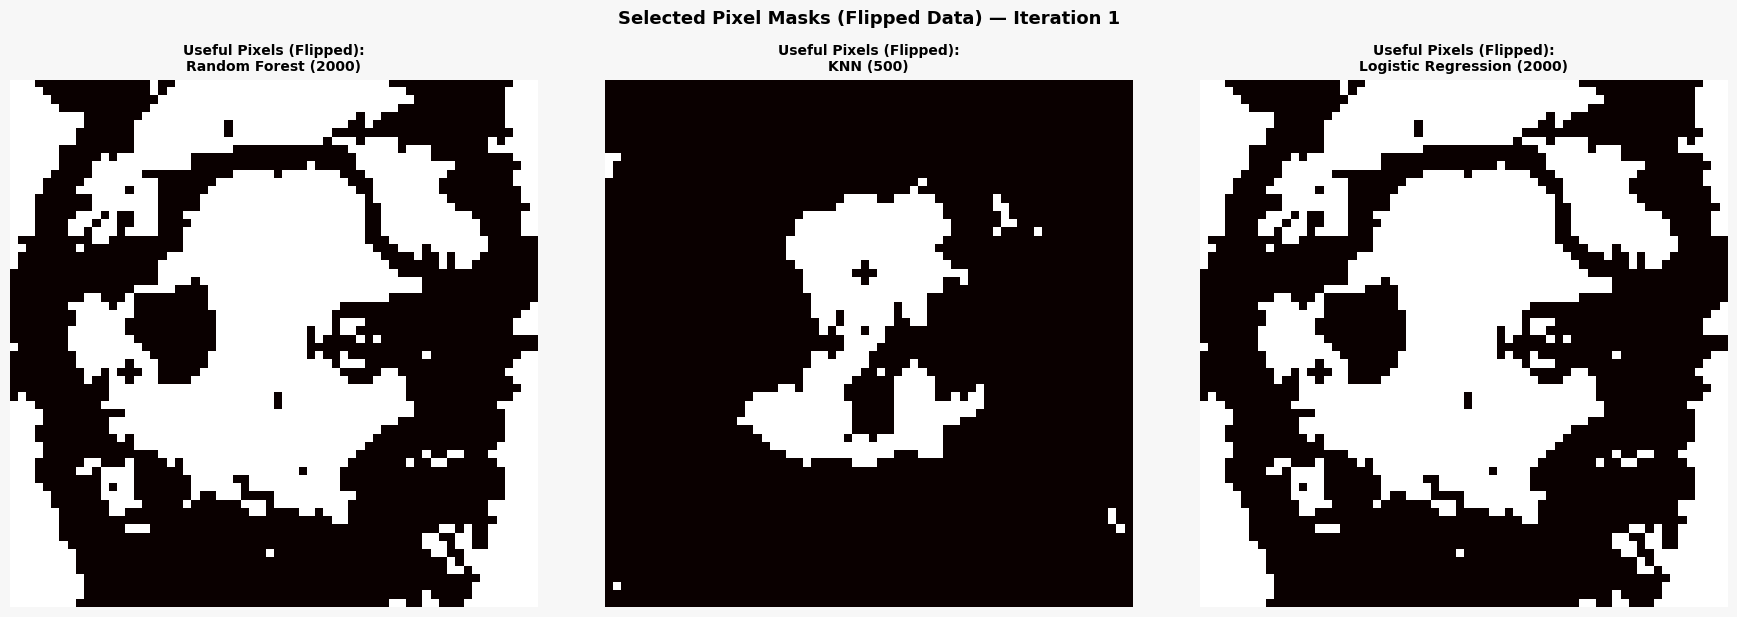


══════════════════════════════════════════════════════════
  ITERATION 2 / 5  —  Theme 2: Image Flip Analysis
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Flip Distribution
──────────────────────────────────────────────────────────


,Set,Total Cats,Flipped Cats,Normal Cats,Total Dogs,Flipped Dogs,Normal Dogs
0,Training,800,400,400,800,400,400
1,Test,200,100,100,200,100,100



──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.6344    0.6219          0.5844
        50  │           0.6787    0.6162          0.5637
       100  │           0.7000    0.6294          0.5694
       500  │           0.7156    0.6912          0.5513
      1000  │           0.7250    0.6825          0.5725
      2000  │           0.7400    0.6400          0.5919
      4096  │           0.7238    0.6244          0.5875


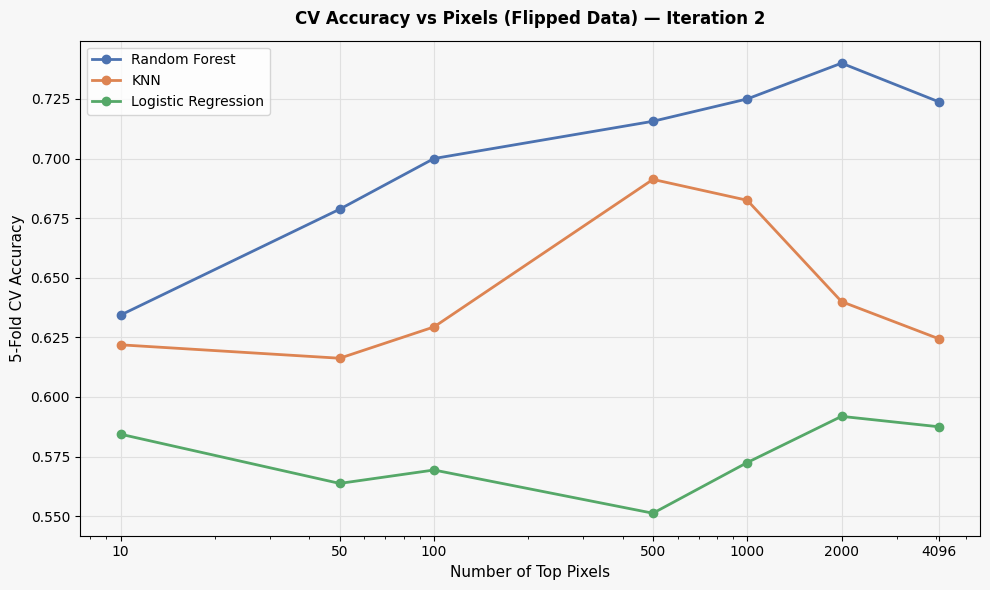


──────────────────────────────────────────────────────────
  Best Config per Model  (Flipped Data)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                     2000      0.7400
  KNN                                500      0.6912
  Logistic Regression               2000      0.5919

──────────────────────────────────────────────────────────
  Final Test Evaluation (Flipped Data)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest               2000          0.6925
  KNN                          500          0.6375
  Logistic Regression         2000          0.5800


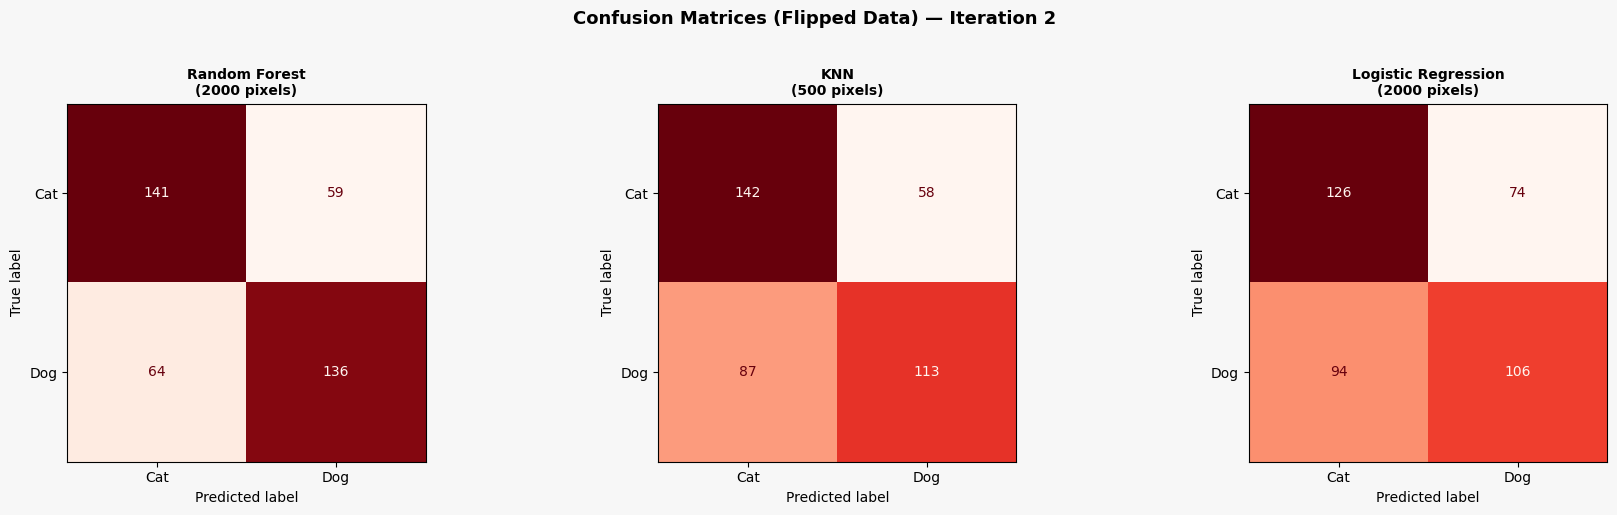

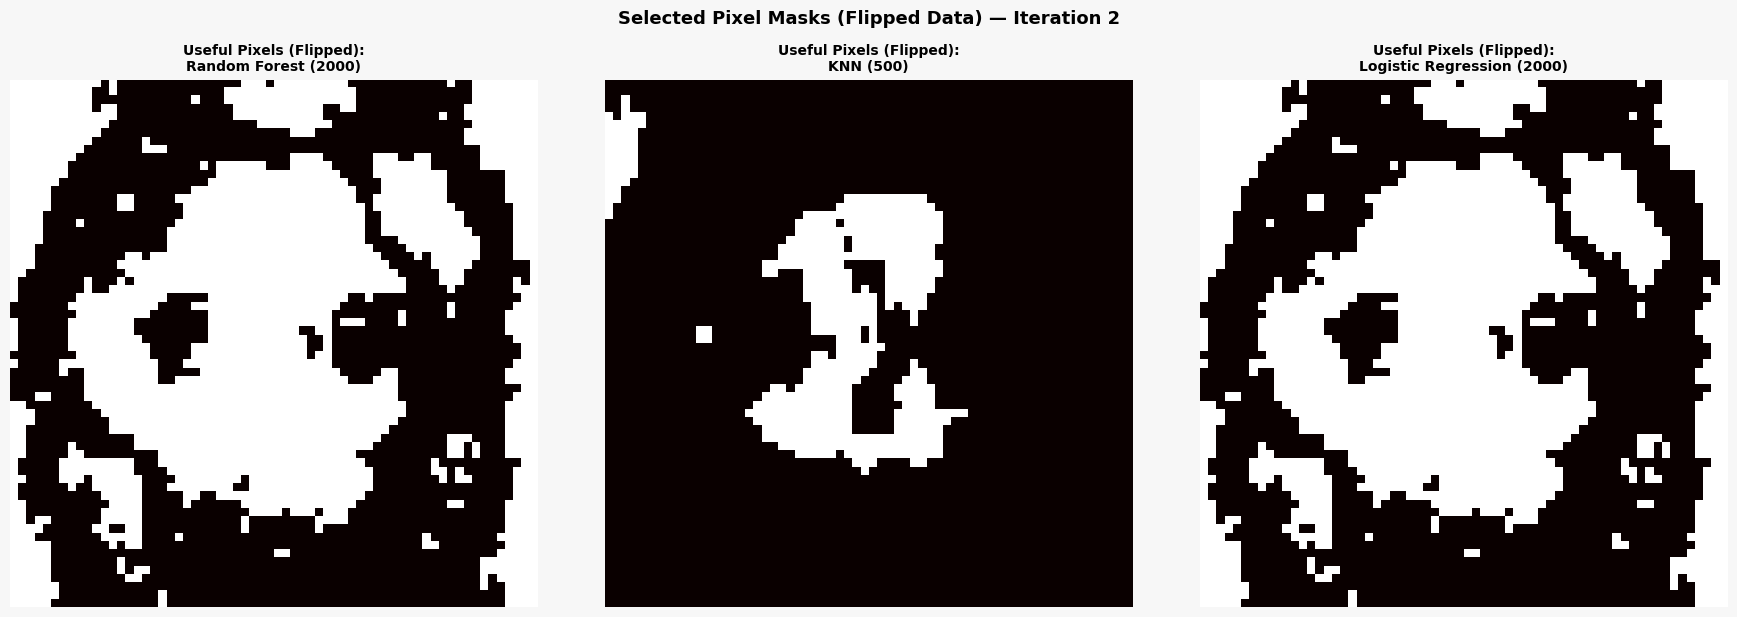


══════════════════════════════════════════════════════════
  ITERATION 3 / 5  —  Theme 2: Image Flip Analysis
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Flip Distribution
──────────────────────────────────────────────────────────


,Set,Total Cats,Flipped Cats,Normal Cats,Total Dogs,Flipped Dogs,Normal Dogs
0,Training,800,400,400,800,400,400
1,Test,200,100,100,200,100,100



──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.5919    0.5800          0.5506
        50  │           0.6512    0.6050          0.5531
       100  │           0.6675    0.6094          0.5306
       500  │           0.6975    0.6644          0.5981
      1000  │           0.7094    0.6550          0.5925
      2000  │           0.7194    0.6300          0.6050
      4096  │           0.7294    0.6194          0.6056


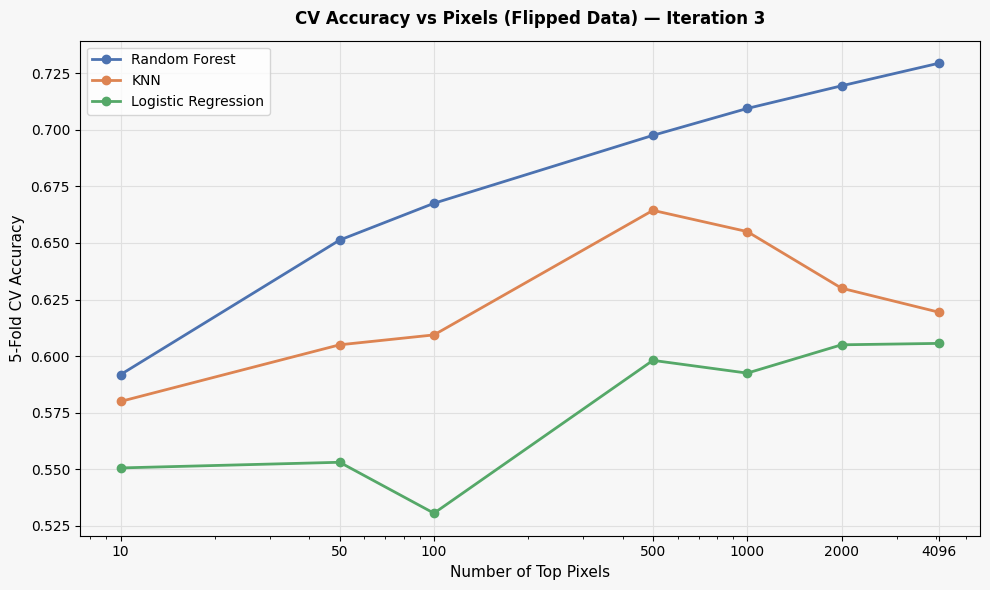


──────────────────────────────────────────────────────────
  Best Config per Model  (Flipped Data)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                     4096      0.7294
  KNN                                500      0.6644
  Logistic Regression               4096      0.6056

──────────────────────────────────────────────────────────
  Final Test Evaluation (Flipped Data)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest               4096          0.7475
  KNN                          500          0.6825
  Logistic Regression         4096          0.6000


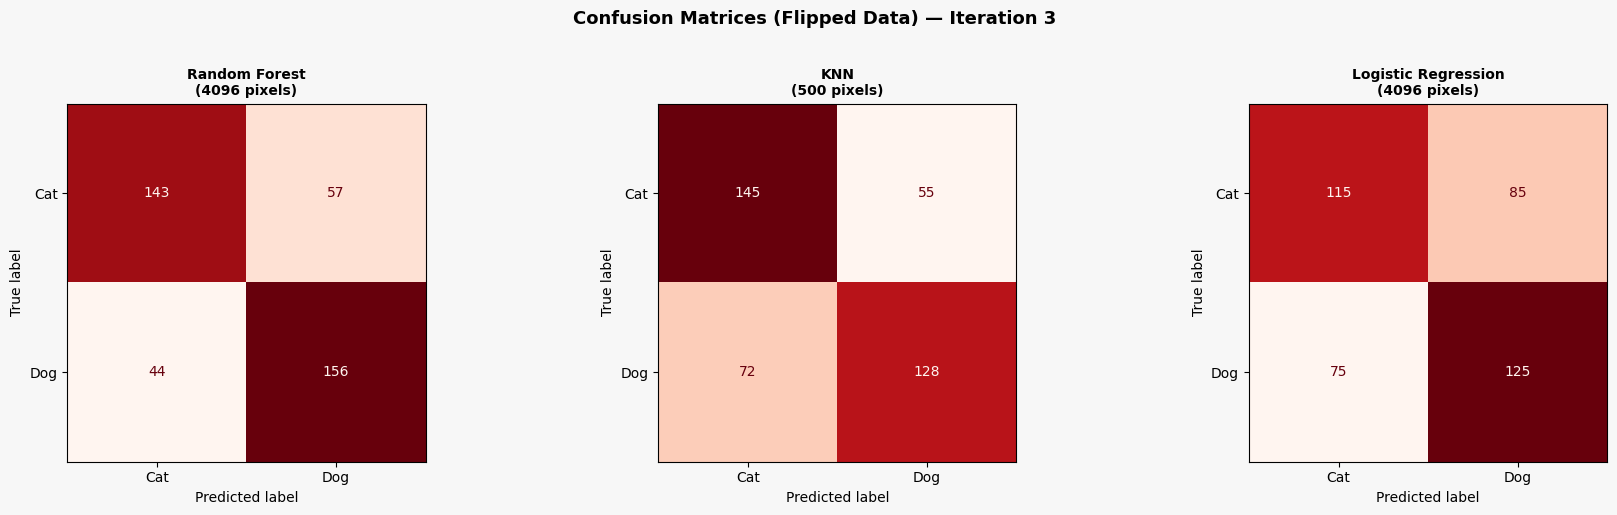

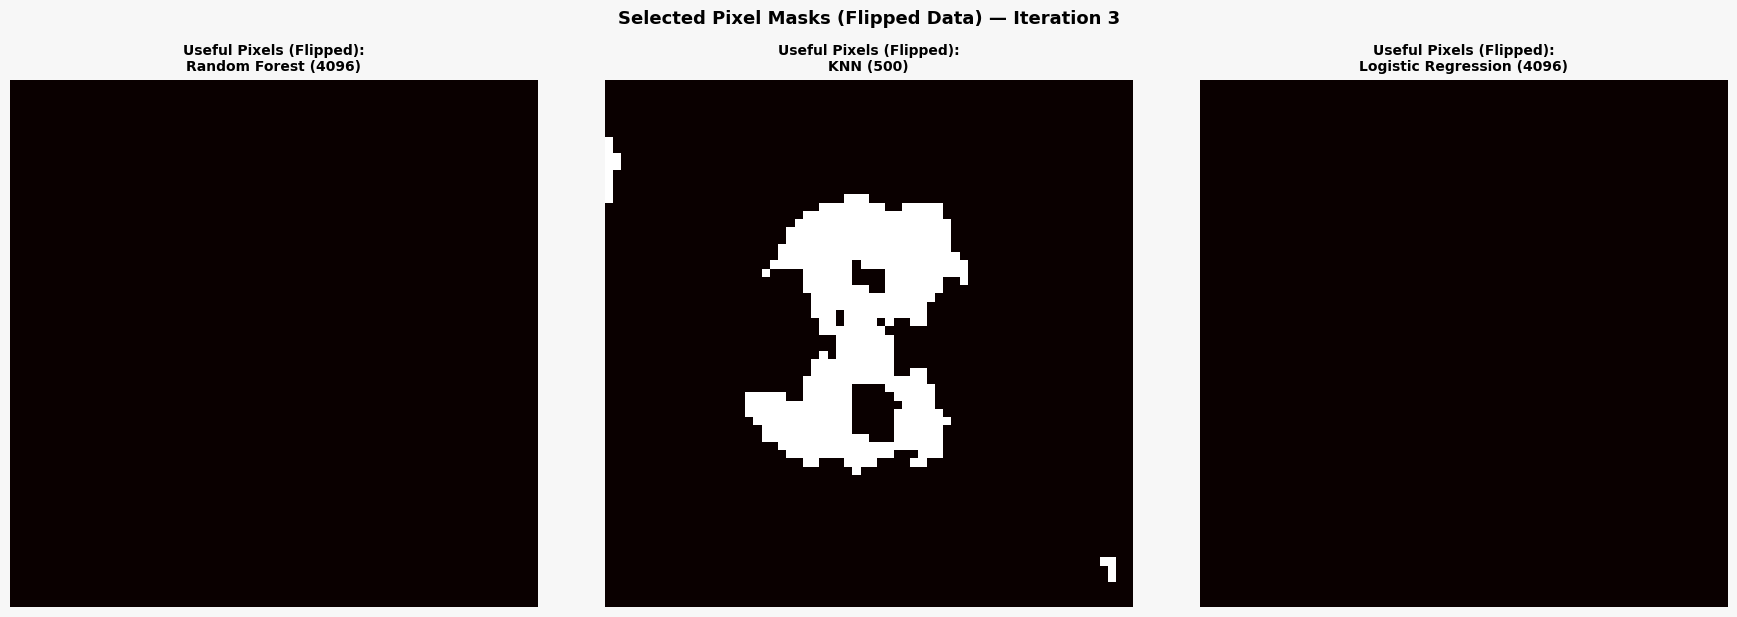


══════════════════════════════════════════════════════════
  ITERATION 4 / 5  —  Theme 2: Image Flip Analysis
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Flip Distribution
──────────────────────────────────────────────────────────


,Set,Total Cats,Flipped Cats,Normal Cats,Total Dogs,Flipped Dogs,Normal Dogs
0,Training,800,400,400,800,400,400
1,Test,200,100,100,200,100,100



──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.6069    0.5900          0.5744
        50  │           0.6544    0.5869          0.5550
       100  │           0.6794    0.6062          0.5275
       500  │           0.7094    0.6744          0.5437
      1000  │           0.7156    0.6644          0.5569
      2000  │           0.6962    0.6562          0.5800
      4096  │           0.7275    0.6306          0.5819


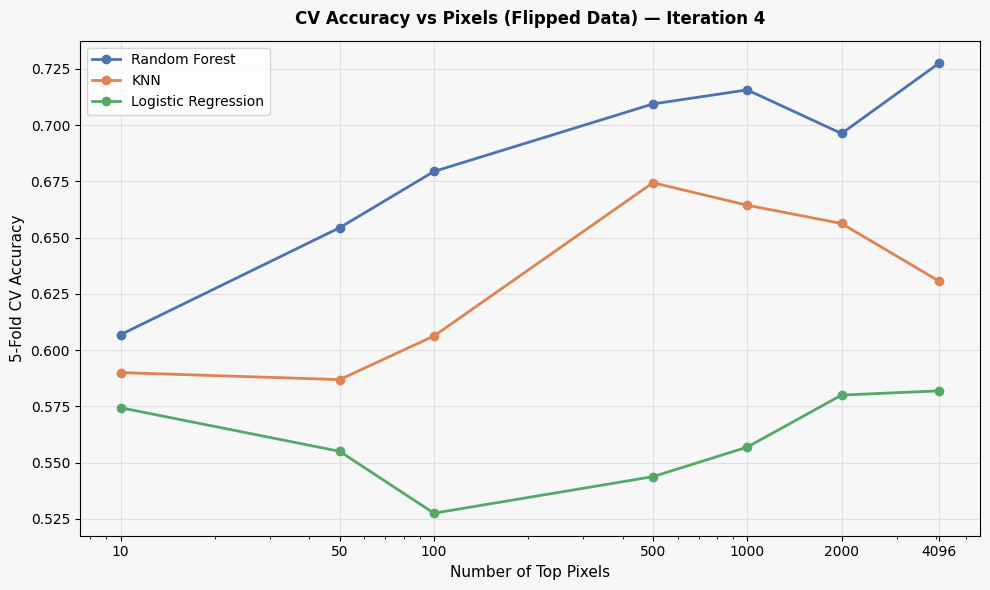


──────────────────────────────────────────────────────────
  Best Config per Model  (Flipped Data)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                     4096      0.7275
  KNN                                500      0.6744
  Logistic Regression               4096      0.5819

──────────────────────────────────────────────────────────
  Final Test Evaluation (Flipped Data)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest               4096          0.7325
  KNN                          500          0.6975
  Logistic Regression         4096          0.6425


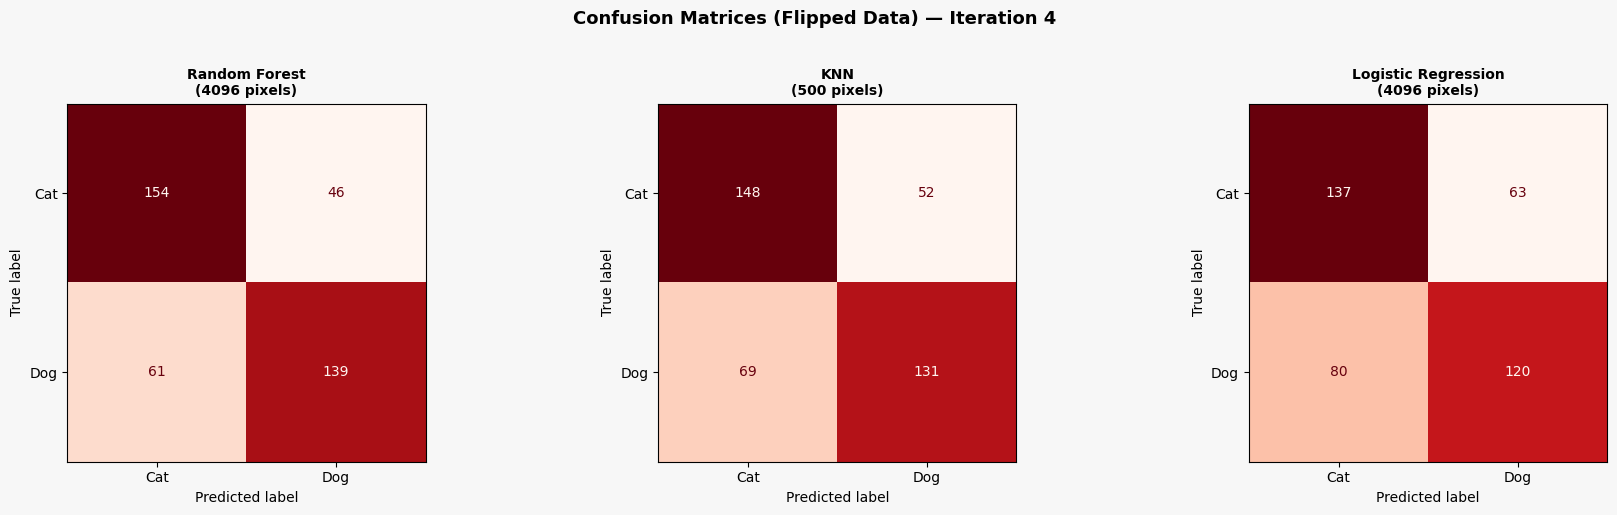

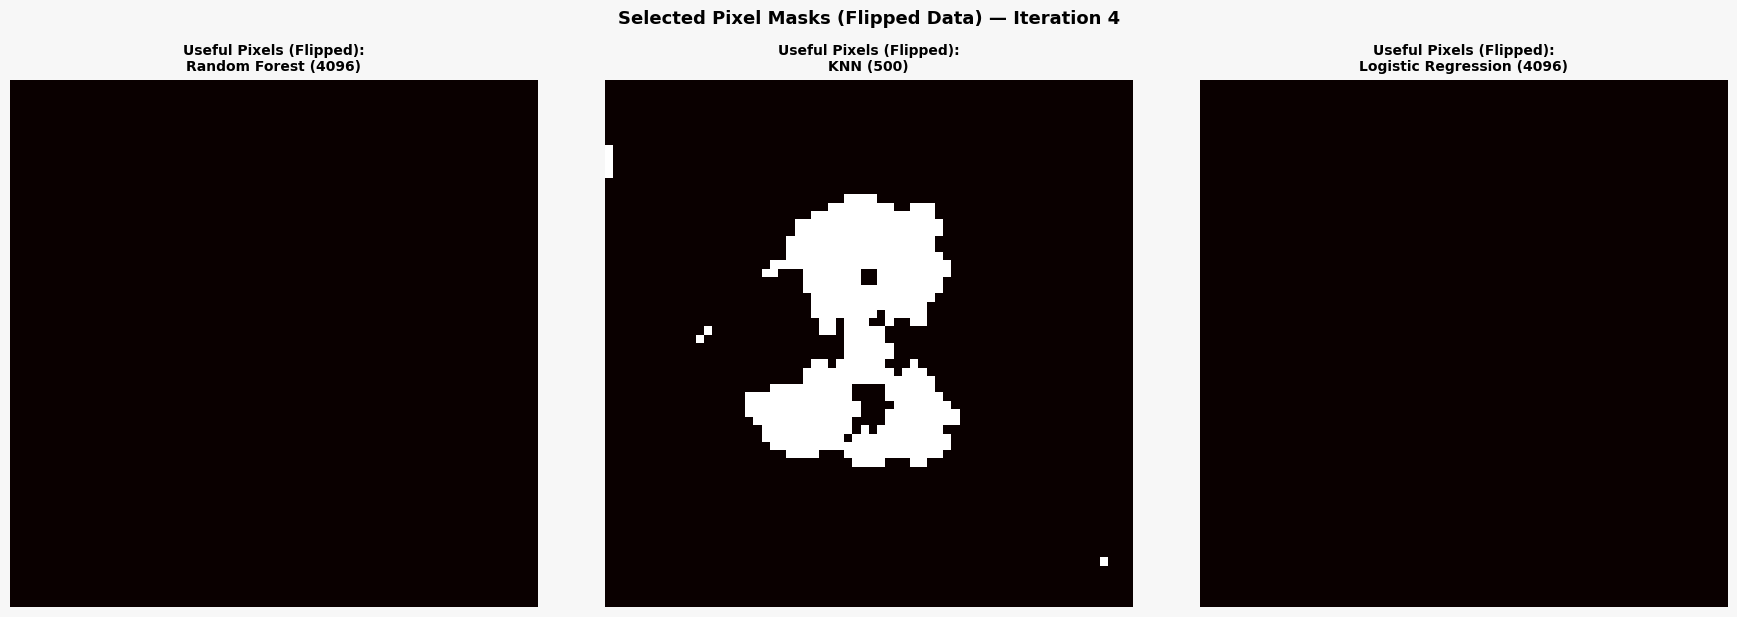


══════════════════════════════════════════════════════════
  ITERATION 5 / 5  —  Theme 2: Image Flip Analysis
══════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────
  Flip Distribution
──────────────────────────────────────────────────────────


,Set,Total Cats,Flipped Cats,Normal Cats,Total Dogs,Flipped Dogs,Normal Dogs
0,Training,800,400,400,800,400,400
1,Test,200,100,100,200,100,100



──────────────────────────────────────────────────────────
  Cross-Validation  (5-Fold, t-test pixel filter)
──────────────────────────────────────────────────────────
  Features  │    Random Forest       KNN    Logistic Reg
  ────────  │  ───────────────  ────────  ──────────────
        10  │           0.5919    0.5756          0.5650
        50  │           0.6650    0.6050          0.5488
       100  │           0.6731    0.6169          0.5425
       500  │           0.7431    0.6844          0.5744
      1000  │           0.7225    0.6756          0.5981
      2000  │           0.7350    0.6294          0.6025
      4096  │           0.7406    0.6331          0.6200


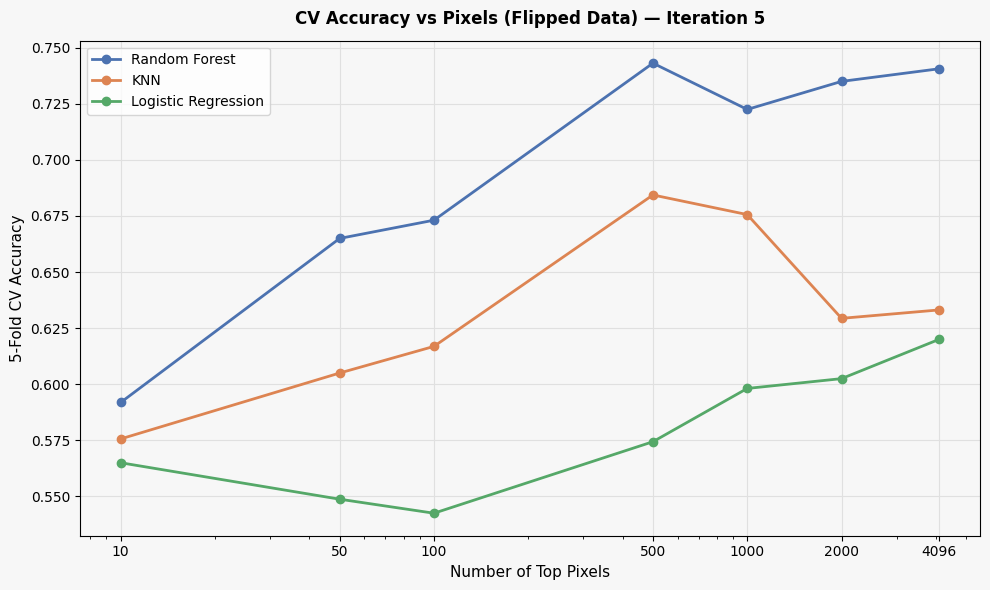


──────────────────────────────────────────────────────────
  Best Config per Model  (Flipped Data)
──────────────────────────────────────────────────────────
  Model                   Optimal Pixels  Max CV Acc
  ──────────────────────  ──────────────  ──────────
  Random Forest                      500      0.7431
  KNN                                500      0.6844
  Logistic Regression               4096      0.6200

──────────────────────────────────────────────────────────
  Final Test Evaluation (Flipped Data)
──────────────────────────────────────────────────────────
  Model                     Pixels   Test Accuracy
  ──────────────────────  ────────  ──────────────
  Random Forest                500          0.7075
  KNN                          500          0.7025
  Logistic Regression         4096          0.5775


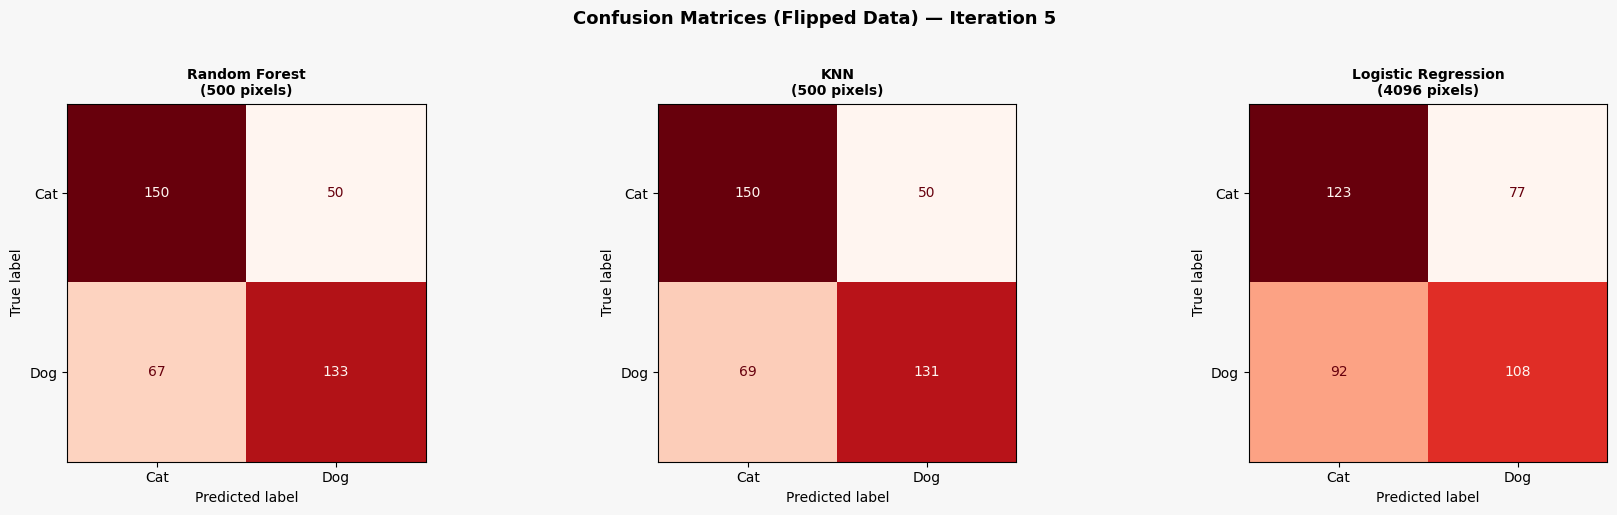

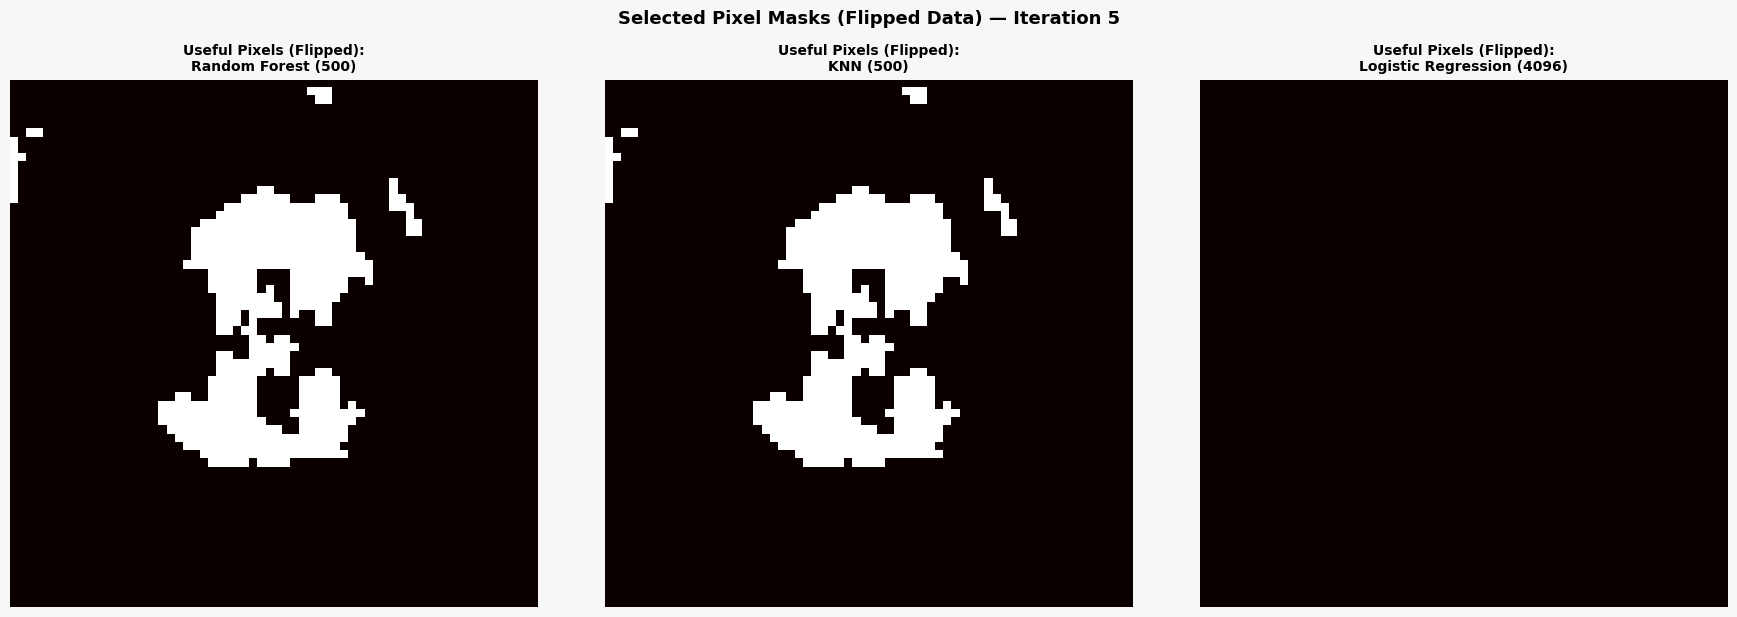

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import ttest_ind

# ── Style (same as Part 1) ─────────────────────────────────────
PALETTE = {
    "Random Forest":       "#4C72B0",
    "KNN":                 "#DD8452",
    "Logistic Regression": "#55A868",
}
BG     = "#F7F7F7"
GRID_C = "#E0E0E0"

num_features_to_test = [10, 50, 100, 500, 1000, 2000, 4096]

def section(title):
    print(f"\n{'─' * 58}")
    print(f"  {title}")
    print(f"{'─' * 58}")

# ── Flip setup — fixed, outside loop ──────────────────────────
X_flip, y_flip = X_sub.copy(), y_sub.copy()
cat_idx, dog_idx = np.where(y_flip == 0)[0], np.where(y_flip == 1)[0]
rng   = np.random.RandomState(42)
cat_f = rng.choice(cat_idx, 500, replace=False)
dog_f = rng.choice(dog_idx, 500, replace=False)

for i in np.concatenate([cat_f, dog_f]):
    X_flip[i] = np.flipud(X_flip[i].reshape(64, 64)).ravel()

flipped_pool = np.concatenate([cat_f, dog_f])

# ── Show sample original vs flipped ───────────────────────────
sample_img  = X_sub[0].reshape(64, 64)
flipped_img = np.flipud(sample_img)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.patch.set_facecolor(BG)
axes[0].imshow(sample_img,  cmap='gray'); axes[0].set_title("Original");            axes[0].axis('off')
axes[1].imshow(flipped_img, cmap='gray'); axes[1].set_title("Flipped (np.flipud)"); axes[1].axis('off')
plt.tight_layout()
plt.show()

# ── Helper: check flip distribution ───────────────────────────
def check_flip_stats(indices, labels, flip_pool, set_name):
    cats   = indices[labels == 0]
    dogs   = indices[labels == 1]
    f_cats = np.sum(np.isin(cats, flip_pool))
    f_dogs = np.sum(np.isin(dogs, flip_pool))
    return {
        "Set":          set_name,
        "Total Cats":   len(cats),
        "Flipped Cats": f_cats,
        "Normal Cats":  len(cats) - f_cats,
        "Total Dogs":   len(dogs),
        "Flipped Dogs": f_dogs,
        "Normal Dogs":  len(dogs) - f_dogs,
    }

# ── Helper: manual 80/20 split preserving flip balance ────────
def get_split(all_idx, flip_idx, seed):
    norm_idx       = np.setdiff1d(all_idx, flip_idx)
    tr_f, te_f     = train_test_split(flip_idx, test_size=0.2, random_state=seed)
    tr_n, te_n     = train_test_split(norm_idx, test_size=0.2, random_state=seed)
    return np.concatenate([tr_f, tr_n]), np.concatenate([te_f, te_n])

# ══════════════════════════════════════════════════════════════
for count in range(5):

    print(f"\n{'═' * 58}")
    print(f"  ITERATION {count + 1} / 5  —  Theme 2: Image Flip Analysis")
    print(f"{'═' * 58}")

    # Different split each iteration via seed=count
    tr_cat, te_cat = get_split(cat_idx, cat_f, seed=count)
    tr_dog, te_dog = get_split(dog_idx, dog_f, seed=count)

    train_idx = np.concatenate([tr_cat, tr_dog])
    test_idx  = np.concatenate([te_cat, te_dog])
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    X_train_flip, y_train_flip = X_flip[train_idx], y_flip[train_idx]
    X_test_flip,  y_test_flip  = X_flip[test_idx],  y_flip[test_idx]

    # ── Flip distribution stats ────────────────────────────────
    section("Flip Distribution")
    stats_tr = check_flip_stats(train_idx, y_train_flip, flipped_pool, "Training")
    stats_te = check_flip_stats(test_idx,  y_test_flip,  flipped_pool, "Test")
    display(pd.DataFrame([stats_tr, stats_te]))

    # ── Cross-validation ───────────────────────────────────────
    results_flip = {name: [] for name in models}
    skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=count)

    section("Cross-Validation  (5-Fold, t-test pixel filter)")
    print(f"  {'Features':>8}  │  {'Random Forest':>15}  {'KNN':>8}  {'Logistic Reg':>14}")
    print(f"  {'─'*8}  │  {'─'*15}  {'─'*8}  {'─'*14}")

    for n in num_features_to_test:
        fold_results = {name: [] for name in models}

        for tr_idx_cv, val_idx_cv in skf.split(X_train_flip, y_train_flip):
            X_tr_cv,  X_val_cv  = X_train_flip[tr_idx_cv],  X_train_flip[val_idx_cv]
            y_tr_cv,  y_val_cv  = y_train_flip[tr_idx_cv],  y_train_flip[val_idx_cv]

            # t-test on training fold only — no leakage
            cats_f    = X_tr_cv[y_tr_cv == 0]
            dogs_f    = X_tr_cv[y_tr_cv == 1]
            t_stats_f, _ = ttest_ind(cats_f, dogs_f, axis=0)
            top_idx   = np.argsort(np.abs(t_stats_f))[::-1][:n]

            for name, clf_fn in models.items():
                clf = clf_fn()
                clf.fit(X_tr_cv[:, top_idx], y_tr_cv)
                fold_results[name].append(clf.score(X_val_cv[:, top_idx], y_val_cv))

        row_scores = []
        for name in models:
            mean_acc = np.mean(fold_results[name])
            results_flip[name].append(mean_acc)
            row_scores.append(f"{mean_acc:.4f}")

        print(f"  {n:>8d}  │  {row_scores[0]:>15}  {row_scores[1]:>8}  {row_scores[2]:>14}")

    # ── CV accuracy plot ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    for name, scores in results_flip.items():
        ax.plot(num_features_to_test, scores,
                marker='o', linewidth=2, markersize=6,
                label=name, color=PALETTE[name])

    ax.set_title(f'CV Accuracy vs Pixels (Flipped Data) — Iteration {count + 1}',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Number of Top Pixels', fontsize=11)
    ax.set_ylabel('5-Fold CV Accuracy',   fontsize=11)
    ax.set_xscale('log')
    ax.set_xticks(num_features_to_test)
    ax.set_xticklabels(num_features_to_test)
    ax.grid(True, color=GRID_C, linewidth=0.8)
    ax.legend(frameon=True, fontsize=10)
    plt.tight_layout()
    plt.show()

    # ── Best config per model ──────────────────────────────────
    best_flip = get_best_n_per_model(results_flip, num_features_to_test)

    section("Best Config per Model  (Flipped Data)")
    print(f"  {'Model':22s}  {'Optimal Pixels':>14}  {'Max CV Acc':>10}")
    print(f"  {'─'*22}  {'─'*14}  {'─'*10}")
    for model, (n, acc) in best_flip.items():
        print(f"  {model:22s}  {n:>14d}  {acc:>10.4f}")

    # ── Final feature selection on full training set ───────────
    cats_tr_f  = X_train_flip[y_train_flip == 0]
    dogs_tr_f  = X_train_flip[y_train_flip == 1]
    t_stats_final_f, _ = ttest_ind(cats_tr_f, dogs_tr_f, axis=0)
    abs_t_final_f      = np.argsort(np.abs(t_stats_final_f))[::-1]

    optimal_feature_sets_flip = {
        model_name: abs_t_final_f[:n]
        for model_name, (n, _) in best_flip.items()
    }

    # ── Final test evaluation ──────────────────────────────────
    section("Final Test Evaluation (Flipped Data)")
    print(f"  {'Model':22s}  {'Pixels':>8}  {'Test Accuracy':>14}")
    print(f"  {'─'*22}  {'─'*8}  {'─'*14}")

    for model_name, indices in optimal_feature_sets_flip.items():
        clf = models[model_name]()
        clf.fit(X_train_flip[:, indices], y_train_flip)
        test_acc = clf.score(X_test_flip[:, indices], y_test_flip)
        print(f"  {model_name:22s}  {len(indices):>8d}  {test_acc:>14.4f}")

    # ── Confusion matrices ─────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor(BG)
    fig.suptitle(f'Confusion Matrices (Flipped Data) — Iteration {count + 1}',
                 fontsize=13, fontweight='bold', y=1.02)

    for i, (model_name, indices) in enumerate(optimal_feature_sets_flip.items()):
        clf = models[model_name]()
        clf.fit(X_train_flip[:, indices], y_train_flip)
        y_pred = clf.predict(X_test_flip[:, indices])

        cm   = confusion_matrix(y_test_flip, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
        disp.plot(ax=axes[i], cmap='Reds', colorbar=False)
        axes[i].set_facecolor(BG)
        axes[i].set_title(f"{model_name}\n({len(indices)} pixels)",
                          fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ── Pixel importance maps ──────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor(BG)
    fig.suptitle(f'Selected Pixel Masks (Flipped Data) — Iteration {count + 1}',
                 fontsize=13, fontweight='bold', y=1.02)

    for i, (model_name, indices) in enumerate(optimal_feature_sets_flip.items()):
        mask          = np.zeros(4096)
        mask[indices] = 1
        mask_img      = mask.reshape(64, 64)

        axes[i].imshow(mask_img, cmap='hot')
        axes[i].set_title(f"Useful Pixels (Flipped):\n{model_name} ({len(indices)})",
                          fontsize=10, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## Summary of Model Performance Across Iterations

To ensure the results are robust and not a random fluke, we repeated the training and evaluation process across 5 random splits. Below is the summary of the optimal feature count found via CV and the resulting test accuracy.

| Iteration | Random Forest (Pixels / Acc) | KNN (Pixels / Acc) | Logistic Regression (Pixels / Acc) |
|:---:|:---:|:---:|:---:|
| **1** | 2000 / 0.7050 | 500 / 0.6375 | 2000 / 0.5650 |
| **2** | 2000 / 0.6925 | 500 / 0.6375 | 2000 / 0.5800 |
| **3** | 4096 / 0.7475 | 500 / 0.6825 | 4096 / 0.6000 |
| **4** | 4096 / 0.7375 | 500 / 0.6975 | 4096 / 0.6425 |
| **5** | 500 / 0.7075 | 500 / 0.7025 | 4096 / 0.5775 |


Best t-test pixels for each model:
- Random Forest - 2000 or 4096 (2/5 Iterations Each)
- KNN - 500 (5/5 Iterations)
- Logistic Regression - 4096 (3/5 Iterations)



**How flipping affected accuracy:**
- All three models dropped significantly. RF went from ~0.87 to ~0.72, KNN from ~0.76 to ~0.67, and LR from ~0.77 to ~0.59. Flipping half the images means the classifier sees two versions of the same class, normal and upside-down, making cats and dogs harder to separate since the pixel patterns within each class are now contradictory even though the labels are the same.

**How flipping affected feature selection**
- KNN remained the most stable, consistently choosing 500 pixels across all iterations, confirming it as the most robust model under this data corruption. Random Forest became even more unstable, splitting evenly between 2000 and 4096 across runs compared to a relatively clearer preference in Part 1. Logistic Regression also lost stability, dropping from choosing 4096 in all 5 runs to only 3 out of 5.